# **Sensado fisiológico para la detección del estrés en entornos virtuales**

### **Ciencia de Datos para Sensores Inteligentes**

*Alumna: Cielo Aholiva Higuera Gutiérrez*

El avance de la tecnología de realidad virtual (VR) ha transformado la manera en que las personas interactúan con los entornos simulados, ofreciendo experiencias inmersas con aplicaciones de entretenimiento, salud mental, educación y entretenimiento profesional. Sin embargo, esta inmersión también puede provocar respuestas fisiológicas intensas, especialmente en usuarios con baja familiaridad o alta sensibilidad emocional, haciendo crucial el monitorio del estrés en tiempo real.

En el contexto de la realidad virtual, donde los entornos pueden ser altamente inmersivos y emocionalmente intensos, monitorear y modelar la respuesta fisiológica se vuelve clave. El análisis de estas señales no solo permite entender la respuesta emocional del usuario, sino que también permite detectar con precisión los momentos de mayor estrés durante la experiencia.

Por ello, el objetivo de este estudio es identificar y clasificar los niveles de estrés en un entorno virtual a partir de datos fisiológicos, y evaluarlo mediante técnicas de procesamiento de datos, clustering y modelos de aprendizaje automático.

**Recolección de datos**

Se incluyeron 10 participantes en el estudio. Previo al inicio de la actividad, cada sujeto fue sometido a un breve protocolo de relajación basal con el fin de estabilizar su ritmo cardíaco antes de la recolección de datos. Posteriormente, se les colocó el sensor de frecuencia cardíaca Polar H10.

Antes de comenzar con las tareas principales, los participantes completaron un tutorial introductorio, diseñado para familiarizarlos con el entorno virtual. Una vez finalizada esta etapa, se les pidió que realizaran una serie de desafíos dentro de un entorno de realidad virtual temáticamente asociado a una fobia específica: los payasos. Este entorno fue diseñado para provocar diferentes niveles de respuesta emocional, incluyendo situaciones de tensión, interacción activa y sobresaltos controlados.

Durante toda la experiencia, se registraron tanto los datos fisiológicos como la segmentación temporal de cada evento vivido, permitiendo relacionar los cambios fisiológicos con momentos específicos dentro del entorno virtual.


In [2]:
from IPython.display import Image
Image('/content/drive/MyDrive/CDSI/Proyecto/ChatGPT Image 2 abr 2025, 03_49_13 p.m..png')


Output hidden; open in https://colab.research.google.com to view.

#### **Importamos librerías**

In [ ]:
!pip install heartpy --quiet
!pip install neurokit2 --quiet
!pip install xgboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.1/693.1 kB 12.3 MB/s eta 0:00:00


In [ ]:
# system libraries
import os
import sys
import re

# data
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import heartpy as hp
import neurokit2 as nk

# Filtro Savistsky-Golay
from scipy.signal import savgol_filter

# model
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.validation import check_array
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from lime.lime_tabular import LimeTabularExplainer



import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### **Análisis exploratorio de datos**

In [ ]:
# Ruta a la carpeta de archivos HRV
dir_practice = "/content/drive/MyDrive/CDSI/Proyecto/Datos"

def cargar_datos_desde_archivo(archivo):
    datos = []
    with open(archivo, 'r') as f:
        for linea in f:
            try:
                datos.append(float(linea.strip()))
            except ValueError:
                print(f"Advertencia: Línea ignorada en {archivo}: {linea.strip()}")
    return datos

In [ ]:
etiquetado = pd.read_csv("/content/drive/MyDrive/CDSI/Proyecto/Heart_Rate_VR_Data.csv")
display(etiquetado.head())

,user,sex,VR experience,heart/stress,time,event,stress level,heart rate file
0,scarlett,0,0,0,00:00,start tutorial,0,scarlett.txt
1,scarlett,0,0,0,00:45,features game,0,scarlett.txt
2,scarlett,0,0,0,02:40,open door,1,scarlett.txt
3,scarlett,0,0,0,03:08,bend down,1,scarlett.txt
4,scarlett,0,0,1,04:11,climb stairs,2,scarlett.txt


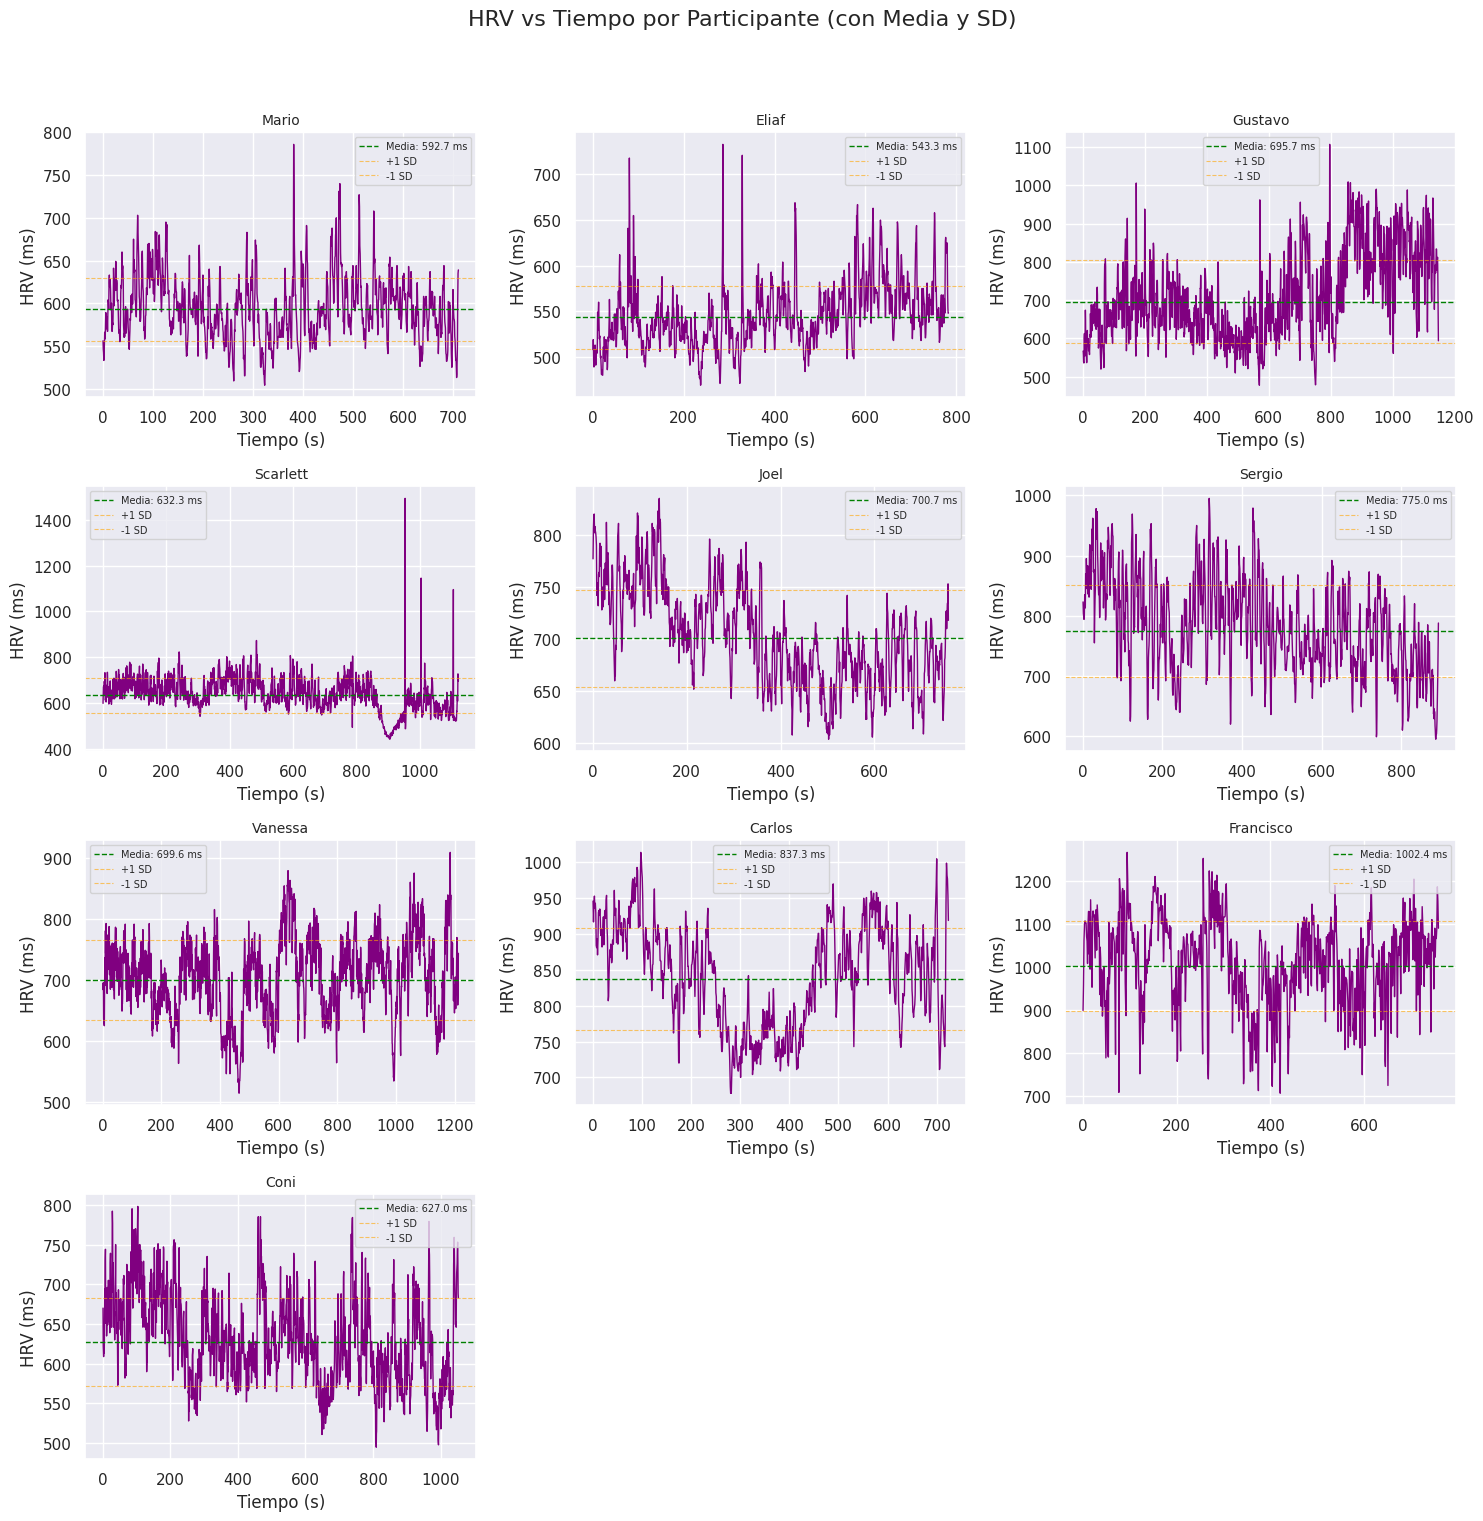

In [ ]:
sns.set_theme()
def calcular_tiempos_acumulados(datos_hrv):
    tiempos_acumulados = [0]
    for valor_hrv in datos_hrv:
        tiempo_segundos = valor_hrv / 1000
        tiempos_acumulados.append(tiempos_acumulados[-1] + tiempo_segundos)
    return tiempos_acumulados[1:]

dir_practice = "/content/drive/MyDrive/CDSI/Proyecto/Datos"
archivos_txt = [os.path.join(dir_practice, archivo) for archivo in os.listdir(dir_practice) if archivo.lower().endswith('.txt')]

n = len(archivos_txt)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), sharex=False)
axes = axes.flatten()

for idx, archivo in enumerate(archivos_txt):
    nombre_archivo = os.path.basename(archivo).replace(".txt", "").replace("_", " ").title()
    datos_hrv = cargar_datos_desde_archivo(archivo)

    if not datos_hrv:
        continue

    tiempos = calcular_tiempos_acumulados(datos_hrv)
    media = np.mean(datos_hrv)
    std = np.std(datos_hrv)

    ax = axes[idx]
    ax.plot(tiempos, datos_hrv, color='purple', linewidth=1)

    # Líneas estadísticas
    ax.axhline(media, color='green', linestyle='--', linewidth=1, label=f"Media: {media:.1f} ms")
    ax.axhline(media + std, color='orange', linestyle='--', linewidth=0.8, alpha=0.6, label='+1 SD')
    ax.axhline(media - std, color='orange', linestyle='--', linewidth=0.8, alpha=0.6, label='-1 SD')

    ax.set_title(nombre_archivo, fontsize=10)
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("HRV (ms)")
    ax.grid(True)
    ax.legend(fontsize=7)

# Eliminar subplots vacíos
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("HRV vs Tiempo por Participante (con Media y SD)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

En la gráfica obtenida se puede observar lo siguiente:
1. **Variabilidad interindividual clara**: Hay diferencias marcadas entre los participantes en cuanto a sus valores medios y la dispersión de HRV. Por ejemplo: los datos de Francisco presentan los valores más altos (media ≈ 1024 ms), lo que podría indicar alta variabilidad y una buena regulación autonómatica. Así mismo los datos de Eliaf y Coni muestran valores medios más bajos (~543 ms y ~677 ms respectivamente), lo cual podría indicar menor variabilidad.

2. **Participantes con HRV más estable:** Se puede observar que Mario, Scarlett y Joel muestran trayectorias relativamente planas y contenidas dentro del rango ±1 SD, lo que sugiere una respuesta más constante a lo largo del tiempo. Lo que sugiere una menor reactividad fisiológica ante los eventos del entorno virtual.

3. **Participantes con HRV más estable**: Se observa que Gustavo, Carlos y Vanessa tienen oscilaciones más pronunciadas y amplitud alta dentro del rango temporal, lo que podría reflejar una mayor sensibilidad emocional o un mayor dinamismo autonómico.

4. **Picos altos**: Algunos gráficos muestran picos muy puntuales (como Scarlett y Sergio), que podrían estar asociados a momentos específicos del juego.

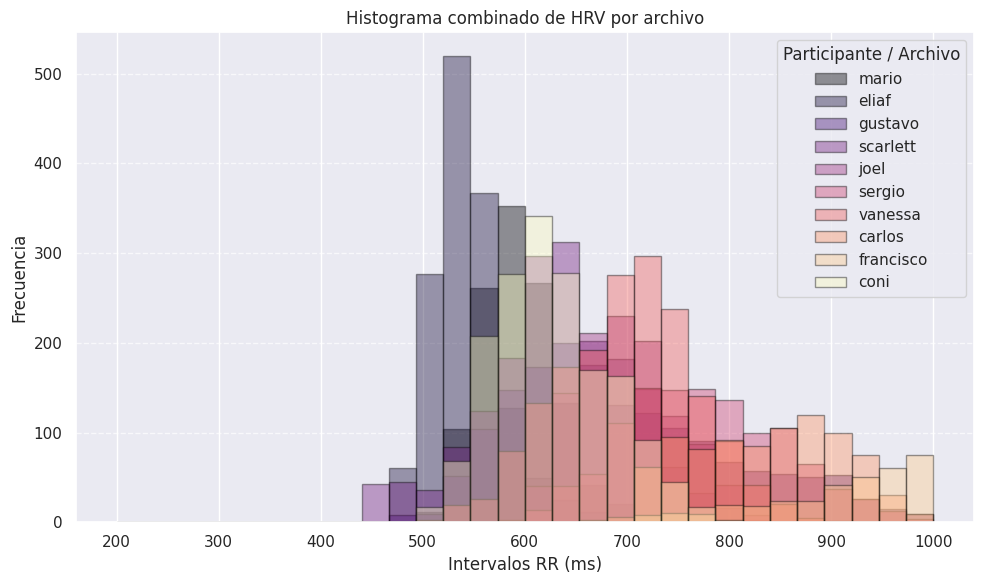

In [ ]:
def generar_histograma_superpuesto(archivos_txt):
    plt.figure(figsize=(10, 6))
    colores = plt.cm.magma(np.linspace(0, 1, len(archivos_txt)))

    for i, archivo in enumerate(archivos_txt):
        datos_hrv = cargar_datos_desde_archivo(archivo)

        if not datos_hrv:
            print(f"Advertencia: No hay datos en {archivo}")
            continue

        nombre = os.path.basename(archivo).replace(".txt", "")
        plt.hist(datos_hrv, bins=30, range=(200, 1000), alpha=0.4, label=nombre, color=colores[i], edgecolor='black')

    plt.title("Histograma combinado de HRV por archivo")
    plt.xlabel("Intervalos RR (ms)")
    plt.ylabel("Frecuencia")
    plt.legend(title="Participante / Archivo")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Ejecutar el histograma
archivos_txt = [os.path.join(dir_practice, archivo) for archivo in os.listdir(dir_practice) if archivo.lower().endswith('.txt')]
generar_histograma_superpuesto(archivos_txt)

**Observaciones:**

* Los participantes como Eliaf, Mario, Gustavo y Joel tienen distribuciones más concentradas hacia la izquierda (~500-600 ms), lo que podría indicar menores intervalos RR y posible reflejo de mayor activación simpática o niveles sostenidos de estrés.

* Mientras que los participantes como Francisco, Carlos y Coni tienen distribuciones más desplazadas a la derecha (~700-950 ms), lo que indica intervalos RR más largos y posibles signos de mayor relajación.

#### **Integración de los datos fisiológicos con la segmentación de eventos**

In [ ]:
def time_to_seconds(time_str):
    minutes, seconds = map(int, time_str.split(':'))
    return minutes * 60 + seconds

def cargar_contextos_desde_csv(archivo_etiquetado):
    """Carga el CSV de etiquetas y convierte la columna de tiempo a segundos, además agrega la columna 'stress level'."""
    etiquetado = pd.read_csv(archivo_etiquetado)
    # Convertir la columna 'time' a segundos
    etiquetado['time_to_seconds'] = etiquetado['time'].apply(time_to_seconds)
    print("Datos del archivo etiquetado:")
    print(etiquetado.head())
    return etiquetado

def cargar_contexto(etiquetado, tiempo_acumulado, archivo_txt):
    """Obtiene el contexto y el nivel de miedo correspondiente al tiempo dado desde el archivo etiquetado."""
    # Buscar el evento y el nivel de estres basado en el tiempo acumulado
    instancia = etiquetado[(etiquetado['heart rate file'] == archivo_txt) &
                           (etiquetado['time_to_seconds'] <= tiempo_acumulado)]

    if not instancia.empty:
        contexto = instancia['event'].values[-1]  # Obtener el último contexto antes del tiempo acumulado
        fear_level = instancia['stress level'].values[-1]  # Obtener el nivel de miedo
    else:
        contexto = None
        fear_level = None
    return contexto, fear_level

def cargar_datos_desde_carpeta(carpeta_hrv, archivo_etiquetado):
    archivos_txt = [archivo for archivo in os.listdir(carpeta_hrv) if archivo.lower().endswith('.txt')]
    datos_completos = []
    etiquetado = cargar_contextos_desde_csv(archivo_etiquetado)

    for archivo_txt in archivos_txt:
        datos_hrv = cargar_datos_desde_archivo(os.path.join(carpeta_hrv, archivo_txt))
        tiempos_acumulados = calcular_tiempos_acumulados(datos_hrv)

        contextos = []
        stress_levels = []
        for tiempo_acumulado in tiempos_acumulados:
            contexto, stress_level = cargar_contexto(etiquetado, tiempo_acumulado, archivo_txt)
            contextos.append(contexto)
            stress_levels.append(stress_level)

        datos_archivo = pd.DataFrame({
            'filename': archivo_txt,
            'HRV': datos_hrv,
            'Tiempo_Acumulado': tiempos_acumulados,
            'Contexto': contextos,
            'stress_Level': stress_level
        })

        datos_archivo = datos_archivo.dropna()
        datos_completos.append(datos_archivo)

    return pd.concat(datos_completos, ignore_index=True)

# Rutas
carpeta_hrv = '/content/drive/MyDrive/CDSI/Proyecto/Datos'
archivo_etiquetado = '/content/drive/MyDrive/CDSI/Proyecto/Heart_Rate_VR_Data.csv'

datos_completos = cargar_datos_desde_carpeta(carpeta_hrv, archivo_etiquetado)
print(datos_completos.head())

Datos del archivo etiquetado:
       user  sex  VR experience  heart/stress   time           event  \
0  scarlett    0              0             0  00:00  start tutorial   
1  scarlett    0              0             0  00:45   features game   
2  scarlett    0              0             0  02:40       open door   
3  scarlett    0              0             0  03:08       bend down   
4  scarlett    0              0             1  04:11    climb stairs   

   stress level heart rate file  time_to_seconds  
0             0    scarlett.txt                0  
1             0    scarlett.txt               45  
2             1    scarlett.txt              160  
3             1    scarlett.txt              188  
4             2    scarlett.txt              251  
    filename    HRV  Tiempo_Acumulado        Contexto  stress_Level
0  mario.txt  556.0             0.556  start tutorial             0
1  mario.txt  546.0             1.102  start tutorial             0
2  mario.txt  542.0        

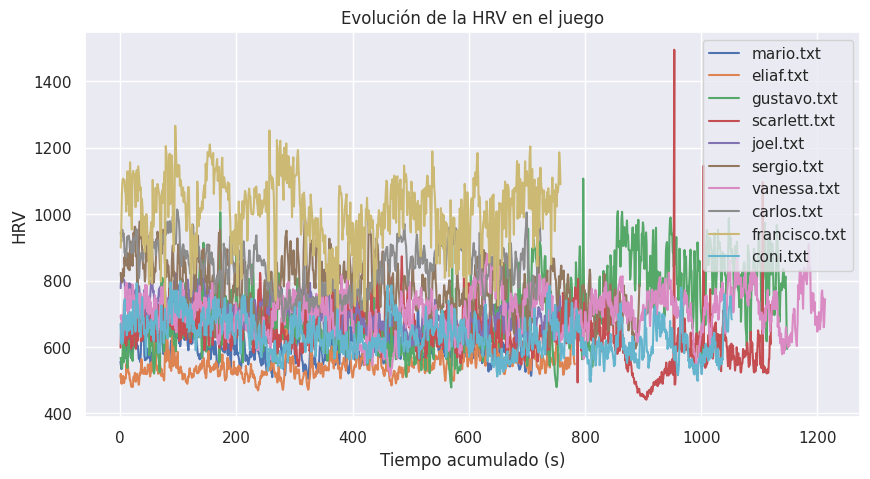

In [ ]:
plt.figure(figsize=(10,5))
for filename in datos_completos["filename"].unique():
    subset = datos_completos[datos_completos["filename"] == filename]
    plt.plot(subset["Tiempo_Acumulado"], subset["HRV"], label=filename)

plt.xlabel("Tiempo acumulado (s)")
plt.ylabel("HRV")
plt.title("Evolución de la HRV en el juego")
plt.legend()
plt.show()

**Observaciones**

* En la figura obtenida permite visualizar de forma continua cómo se comportó el sistema nervioso autónomo de cada participante a lo largo del entorno, proporcionando una base para análisis más detallados por evento o por perfil fisiológico.

   * Participantes como Francisco, Carlos y Coni presentan valores consistentemente altos de HRV, lo que podría indicar una mayor regulación autonómica o un estado de relativa calma fisiológica durante la experiencia. En contraste, participantes como Eliaf, Mario y Gustavo muestran valores más bajos o con menos variabilidad, lo cual puede estar asociado a una activación simpática más sostenida.

   * Además, se identifican momentos de picos o caídas abruptas en la señal (por ejemplo, en Scarlett o Sergio), posiblemente vinculados a eventos estresantes específicos del entorno, como la aparición del payaso o la persecución (clown chase).


*Valores estadísticos por tipo de evento en el entorno virtual.*

In [ ]:
datos_completos['heart rate'] = 60000 / datos_completos['HRV']

# Muestra las estadísticas del data frame
event_heart_rate_stats = datos_completos.groupby('Contexto')['heart rate'].agg(['mean', 'max', 'min'])
print(event_heart_rate_stats)

                      mean         max        min
Contexto                                         
bend down        88.845324  118.577075  50.547599
climb stairs     93.627489  125.260960  51.282051
clown chase      96.592176  136.054422  52.356021
complete a task  88.872508  123.203285  40.133779
end game         90.976013  116.959064  50.590219
features game    84.534860  120.240481  47.393365
open door        86.530603  122.699387  49.586777
relax room       88.076239  127.931770  47.923323
start a task     91.000677  131.004367  49.833887
start game       88.745822  127.388535  56.338028
start tutorial   89.655372  125.000000  51.903114
throw things     87.206896  120.481928  50.462574


* Se observa que el evento "clown chase" presenta el valor promedio de HRV más alto (96.6 ms) y también uno de los máximos más elevados (136.05 ms), lo cual podría reflejar una mayor activación fisiológica en respuesta a este estímulo, que representa un momento de alta tensión o miedo en el juego.

* Otros eventos con valores promedios elevados incluyen "climb stairs" y "end game", posiblemente asociados a esfuerzo físico moderado o al cierre emocional de la experiencia.

* En contraste, eventos como "features game", "open door" y "throw things" presentan valores promedio más bajos de HRV (~84–87 ms), lo que sugiere una menor reactividad fisiológica o momentos de menor carga emocional.

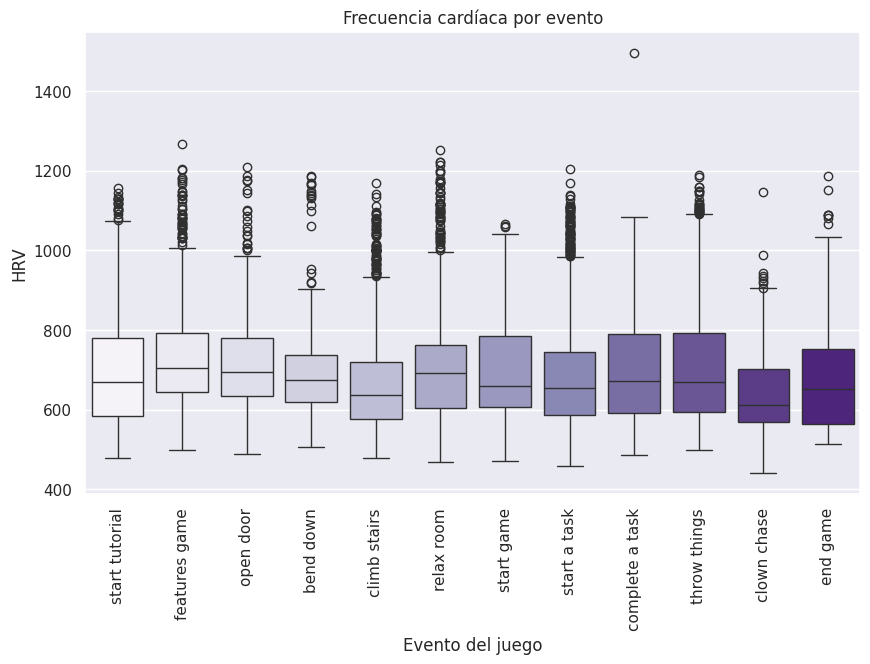

In [ ]:
# Boxplot para visualizar la distribución de la frecuencia cardíaca por evento
datos_completos = datos_completos.rename(columns={'Contexto': 'event'})
plt.figure(figsize=(10, 6))
sns.boxplot(x='event', y='HRV', data=datos_completos, hue='event', palette="Purples", legend=False)
plt.xlabel('Evento del juego')
plt.title('Frecuencia cardíaca por evento')
plt.xticks(rotation=90)
plt.show()

Se realizó una distribución de los valores de HRV por evento en un entorno virtual, lo que permitió visualizar la variabilidad y activación fisiológica asociada a cada fase del juego.

* En donde se observa que los eventos como "clown chase" y "end game" presentan boxplots más desplazados hacia abajo, indicando valores de HRV más bajos, lo que se asocia típicamente a una mayor activación del sistema simpático y, por ende, a una respuesta de estrés más marcada. Esto concuerda con la naturaleza emocionalmente intensa de estos eventos dentro del entorno.

* Por otro lado, eventos como "features game", "start tutorial" y "relax room" presentan valores de HRV más altos en promedio, y con menor dispersión, lo que puede interpretarse como momentos de menor carga emocional o mayor relajación.

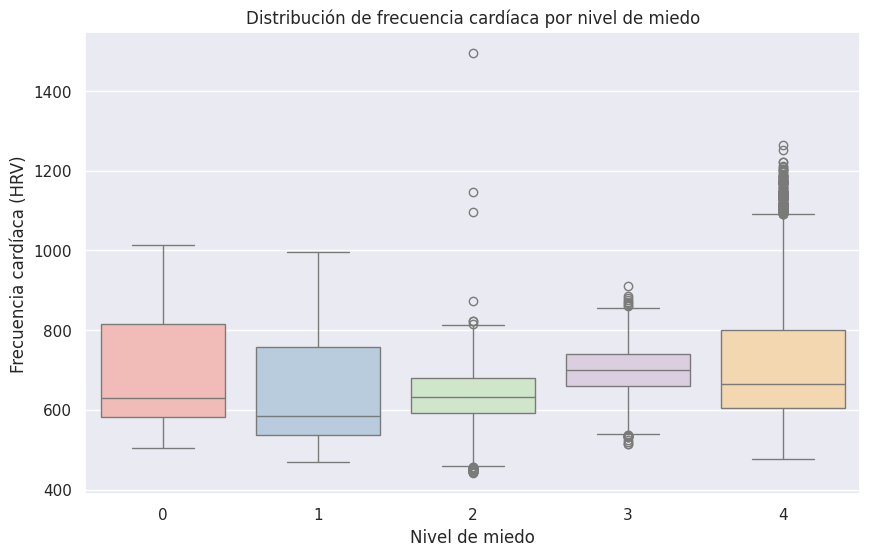

In [ ]:
# Figura para la distribución de frecuencia cardíaca por nivel de miedo
plt.figure(figsize=(10, 6))
sns.boxplot(x='stress_Level', y='HRV', data=datos_completos, hue='stress_Level', palette="Pastel1", legend=False)
plt.title('Distribución de frecuencia cardíaca por nivel de miedo')
plt.xlabel('Nivel de miedo')
plt.ylabel('Frecuencia cardíaca (HRV)')
plt.show()

En la figura se muestra la distribución de los valores de HRV según el nivel subjetivo de estres reportado por los participantes.

* En general, se observa una tendencia a la reducción de la variabilidad cardíaca (HRV) a medida que aumentan los niveles de estres, especialmente entre los niveles 0 a 2, lo que sugiere una activación fisiológica creciente asociada al aumento del estres.

* Esta disminución progresiva en HRV es consistente con lo esperado fisiológicamente: a mayor percepción de estres, se activa el sistema nervioso simpático, reduciendo los intervalos RR (es decir, aumentando la frecuencia cardíaca) y disminuyendo la variabilidad.

* No obstante, en el nivel 4 se observa un aumento leve en la dispersión de HRV, lo que podría deberse a diferencias individuales en la manera en que cada sujeto responde al miedo extremo (algunos podrían haber experimentado una recuperación posterior o respuestas más variables).

*Clusters por eventos*

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/CDSI/Proyecto/datos_limpiados.csv')
data.head()

,filename,HRV,Tiempo_Acumulado,event,stress_Level,heart rate
0,mario.txt,556.0,0.556,start tutorial,0,107.913669
1,mario.txt,546.0,1.102,start tutorial,0,109.890110
2,mario.txt,542.0,1.644,start tutorial,0,110.701107
3,mario.txt,533.0,2.177,start tutorial,0,112.570356
4,mario.txt,536.0,2.713,start tutorial,0,111.940299


In [ ]:
# Función para extraer características por persona
def extraer_caracteristicas(df):
    resultados = []

    for nombre, grupo in df.groupby('filename'):
        grupo = grupo.sort_values('Tiempo_Acumulado').reset_index(drop=True)
        total = len(grupo)
        tercio = total // 3

        hrv_inicio = grupo.loc[:tercio, 'HRV'].mean()
        hrv_medio = grupo.loc[tercio:2*tercio, 'HRV'].mean()
        hrv_final = grupo.loc[2*tercio:, 'HRV'].mean()
        hrv_std = grupo['HRV'].std()
        hrv_total = grupo['HRV'].mean()
        delta_hrv = hrv_inicio - hrv_final

        # Detectar picos de estrés (cambios grandes entre HRVs consecutivos)
        hrv_diff = grupo['HRV'].diff().abs()
        picos_estres = (hrv_diff > hrv_diff.mean() + 2 * hrv_diff.std()).sum()

        resultados.append({
            'filename': nombre,
            'hrv_inicio': hrv_inicio,
            'hrv_medio': hrv_medio,
            'hrv_final': hrv_final,
            'hrv_total': hrv_total,
            'hrv_std': hrv_std,
            'delta_hrv': delta_hrv,
            'picos_estres': picos_estres
        })

    return pd.DataFrame(resultados)

df_resumen = extraer_caracteristicas(data)

In [ ]:
# Seleccionamos características numéricas
X = df_resumen.drop('filename', axis=1)

# Normalizamos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df_resumen['cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
# Ver distribución de personas por cluster
print(df_resumen['cluster'].value_counts())
#
df_clusters = df_resumen.drop(columns=['filename']).groupby('cluster').mean()
print(df_clusters)

cluster
1    7
2    2
0    1
Name: count, dtype: int64
          hrv_inicio   hrv_medio    hrv_final    hrv_total     hrv_std  \
cluster                                                                  
0        1028.537549  977.296443  1002.115079  1002.419312  104.418047   
1         650.295484  629.261561   645.166074   641.538919   60.122313   
2         842.575095  774.636844   801.227061   806.169692   73.979497   

         delta_hrv  picos_estres  
cluster                           
0        26.422470          28.0  
1         5.129411          54.0  
2        41.348035          41.0  


Se realizó un clustering de eventos basado en características temporales del HRV, dividiendo cada registro en segmentos (inicio, medio y final) y evaluando la variación interna y los picos de estrés. El análisis reveló tres grupos bien diferenciados:

* Un clúster minoritario con altos niveles de HRV y baja reactividad, posiblemente asociado a eventos de relajación o participantes poco reactivos.

* Un clúster principal que agrupa la mayoría de los eventos con bajo HRV, alta cantidad de picos de estrés y poca variabilidad, lo que indica una respuesta sostenida de estrés.

* Un grupo intermedio que presenta cambios marcados en el HRV a lo largo del tiempo, sugiriendo eventos con carga emocional creciente o más dinámica.

In [ ]:
data_con_cluster = data.merge(df_resumen[['filename', 'cluster']], on='filename')

# HRV promedio por evento y cluster
eventos_cluster = data_con_cluster.groupby(['event', 'cluster'])['HRV'].agg(['mean', 'std', 'count']).reset_index()

print(eventos_cluster.sort_values('mean'))

              event  cluster         mean         std  count
6       clown chase        1   611.619765  101.706980    597
33     throw things        1   619.017045   53.711571    704
4      climb stairs        1   621.615135   71.694447   2154
30   start tutorial        1   636.288499   88.048363    513
9   complete a task        1   640.674699   94.584109    332
12         end game        1   644.759259   97.856582    162
27       start game        1   644.848671   83.996106    489
1         bend down        1   649.721106   64.091010    398
21       relax room        1   649.959825   81.066785   1145
24     start a task        1   656.168617  100.700422   2734
18        open door        1   668.066514   83.961555    436
15    features game        1   669.871076   69.813879    892
7       clown chase        2   730.754491   55.243325    167
34     throw things        2   758.053763   60.678571    186
5      climb stairs        2   758.786385   49.068729    426
13         end game     

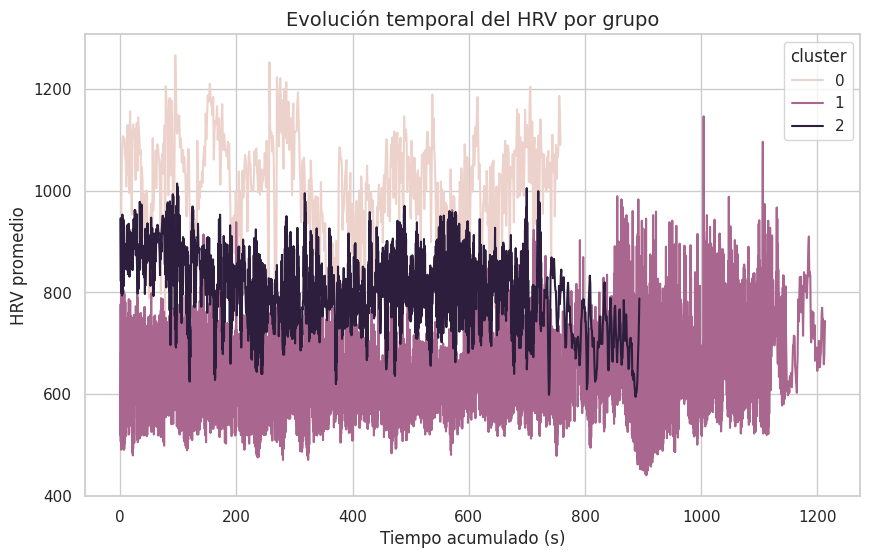

In [ ]:
data_con_cluster['Tiempo_Acumulado'] = data_con_cluster['Tiempo_Acumulado'].round(1)  # agrupar por décimas

df_tiempo = data_con_cluster.groupby(['cluster', 'Tiempo_Acumulado'])['HRV'].mean().reset_index()

# Gráfico
plt.figure(figsize=(10,6))
sns.lineplot(data=df_tiempo, x='Tiempo_Acumulado', y='HRV', hue='cluster')
plt.title('Evolución temporal del HRV por grupo', fontsize=14)
plt.xlabel('Tiempo acumulado (s)')
plt.ylabel('HRV promedio')
plt.grid(True)
plt.show()

**Observaciones**

Se observan los patrones de cada grupo identificado mediante clustering, en donde se distinguen los patrones fisiológicos difertenciados de la siguiente manera:
* Clúster 0 (línea rosada clara) presenta los niveles más altos y estables de HRV (~1000 ms en promedio), lo cual se asocia a una mayor activación del sistema parasimpático, indicando bajo estrés o alta regulación emocional a lo largo del tiempo.

* Clúster 1 (línea púrpura oscura) mantiene valores intermedios de HRV (~850 ms), con una ligera tendencia a la disminución conforme avanza el tiempo, lo que puede reflejar una respuesta gradual de activación fisiológica o fatiga.

* Clúster 2 (línea morada) presenta los valores más bajos de HRV (~650 ms) y mayor fluctuación, lo que indica mayor reactividad fisiológica y menor regulación autonómica, asociado a estados de mayor estrés o tensión emocional.

#### **Extracción de característericas**

Las series temporales de la HRV se generaron a partir de los intervalos RR (tiempo entre latidos cardíacos), medidos en milisegundos. A partir de estos datos se calcularon múltiples características que describen tanto la variabilidad a corto como a largo plazo del ritmo cardíaco. Estas características permiten cuantificar la respuesta del sistema nervioso autónomo ante distintos eventos del entorno virtual:

* SDNN (Desviación Estándar de los Intervalos RR): Mide la variabilidad total de los intervalos RR. Un valor alto refleja una mayor adaptabilidad del sistema cardiovascular.

* RMSSD (Raíz Cuadrada de las Diferencias Cuadráticas Sucesivas): Indica la variabilidad a corto plazo, especialmente sensible a la actividad parasimpática.

* NN50 y pNN50:

  * NN50: Número de pares de intervalos RR consecutivos cuya diferencia es superior a 50 ms.

  * pNN50: Porcentaje de NN50 con respecto al total de intervalos. Ambas métricas reflejan variabilidad a corto plazo.

* SD1 y SD2 (Parámetros del espacio de Poincaré):

  * SD1: Mide la dispersión perpendicular al eje de identidad; asociado a variaciones rápidas del ritmo cardíaco.

  * SD2: Refleja la dispersión a lo largo del eje de identidad; asociado a variabilidad más sostenida.

* LF (Low Frequency) y HF (High Frequency):

  * LF (0.04–0.15 Hz): Relacionado con la actividad simpática y parasimpática.

  * HF (0.15–0.4 Hz): Indicador de actividad parasimpática pura (vagal).

* Relación LF/HF: Estima el balance entre la actividad simpática y parasimpática. Un valor alto indica predominio simpático; un valor bajo, predominio parasimpático.

* TINN (Interpolación Triangular de los Intervalos NN): Representa la amplitud de la base de una distribución triangular interpolada de los intervalos RR. Es útil como medida robusta de variabilidad a largo plazo.

* CVNN (Coeficiente de Variación de los intervalos NN): Calculado como la desviación estándar dividida por la media de los intervalos NN. Representa la variabilidad relativa y permite comparar entre sujetos con diferentes frecuencias cardíacas basales.

* HTI (HRV Triangular Index): Calculado como el número total de intervalos RR dividido entre el número de intervalos contenidos en el histograma de densidad de RR. Este índice ofrece una medida global de la variabilidad y es menos sensible al ruido o artefactos.

Estas características permiten construir vectores de atributos para modelos de clasificación y clustering, y aportan información detallada sobre el estado fisiológico del participante durante su exposición al entorno virtual.

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/CDSI/Proyecto/Heart_Rate_VR_Data.csv")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user             161 non-null    object
 1   sex              161 non-null    int64 
 2   VR experience    161 non-null    int64 
 3   heart/stress     161 non-null    int64 
 4   time             161 non-null    object
 5   event            161 non-null    object
 6   stress level     161 non-null    int64 
 7   heart rate file  161 non-null    object
dtypes: int64(4), object(4)
memory usage: 10.2+ KB


In [ ]:
def time_to_seconds(time_str):
    minutes, seconds = map(int, time_str.split(':'))
    return minutes * 60 + seconds

In [ ]:
# Función para deshacernos de los outliers (en este caso, valores menores a 40 o mayores a 180 BPM)
def remove_outliers(hr_data, lower_bound=40, upper_bound=180):
    hr_data = np.clip(hr_data, lower_bound, upper_bound)
    return hr_data

# Función que aplica el filtro Savitsky-Golay para suavizar señales (disminuir ruido)
def apply_savitzky_golay(hr_data, window_length=7, polyorder=3):
    smoothed_hr = savgol_filter(hr_data, window_length, polyorder)
    return smoothed_hr

# Función de suavizado utilizando filtro de media móvil
def smooth_hr_data(hr_data, window_size=5):
    if window_size % 2 == 0:
        window_size += 1
    smoothed_hr = np.convolve(hr_data, np.ones(window_size) / window_size, mode='same')
    return smoothed_hr

In [ ]:
def extract_kubios_features(time_series, start_time, end_time, min_points=7):
    filtered_data = time_series[(time_series['timestamp'] >= start_time) & (time_series['timestamp'] <= end_time)]

    if len(filtered_data) < min_points:
        print(f"Segmento muy corto entre {start_time}-{end_time}, solo {len(filtered_data)} puntos. Se omite.")
        return None

    try:
        rri = filtered_data['hr'].to_numpy()

        if np.all(np.isnan(rri)) or len(rri) < 3:
            raise ValueError("Serie RR vacía o demasiado corta")

        peaks = nk.intervals_to_peaks(rri)
        hr = 60000 / rri

        # Filtro Savitzky-Golay
        if len(hr) >= 7:
            hr = savgol_filter(hr, 7, 3)
        hr = np.convolve(hr, np.ones(5) / 5, mode='same')

        hrv_results = nk.hrv_time(peaks, sampling_rate=1000, method="kubios")

    except Exception as e:
        print(f"Error processing segment {start_time}-{end_time}. Error: {e}. Returning NaN.")
        columnas = nk.hrv_time(np.array([1, 2]), sampling_rate=1000.0, method="kubios").columns
        return pd.DataFrame(np.nan, index=[0], columns=columnas)

    return hrv_results

In [ ]:
all_event_features = []

# Convertimos la columna de tiempo a segundos
data['time_seconds'] = data['time'].apply(time_to_seconds)

for index, row in data.iterrows():
    user_id = row['user']
    start_time = row['time_seconds']

    hr_file_path = "/content/drive/MyDrive/CDSI/Proyecto/Datos/" + str(row['heart rate file'])

    try:
        hr_data = np.loadtxt(hr_file_path)
    except:
        print(f"No se pudo cargar el archivo {hr_file_path}, se omite.")
        continue

    time_series = pd.DataFrame({'timestamp': np.arange(start_time, start_time + len(hr_data), 1),
                                'hr': hr_data})

    next_event_index = index + 1
    if next_event_index < len(data) and data.loc[next_event_index, 'user'] == user_id:
        end_time = data.loc[next_event_index, 'time_seconds'] - 1
    else:
        end_time = time_series['timestamp'].iloc[-1]

    # Extraer características HRV
    event_features = extract_kubios_features(time_series, start_time, end_time)

    if event_features is None:
        continue

    # Añadir metadatos
    event_features['user'] = user_id
    event_features['event_type'] = row['event']
    event_features['event_start_time'] = start_time
    event_features['event_end_time'] = end_time
    event_features['sex'] = row['sex']
    event_features['VR experience'] = row['VR experience']
    event_features['heart/stress'] = row['heart/stress']
    event_features['stress level'] = row['stress level']

    all_event_features.append(event_features)

# Crear DataFrame final
event_features_df = pd.concat(all_event_features, ignore_index=True)

Segmento muy corto entre 1115-1119, solo 5 puntos. Se omite.
Segmento muy corto entre 1240-1240, solo 1 puntos. Se omite.
Segmento muy corto entre 735-739, solo 5 puntos. Se omite.
Segmento muy corto entre 994-994, solo 1 puntos. Se omite.
Segmento muy corto entre 713-713, solo 1 puntos. Se omite.
Segmento muy corto entre 756-760, solo 5 puntos. Se omite.
Segmento muy corto entre 354-359, solo 6 puntos. Se omite.
Segmento muy corto entre 512-513, solo 2 puntos. Se omite.
Segmento muy corto entre 687-692, solo 6 puntos. Se omite.
Segmento muy corto entre 418-422, solo 5 puntos. Se omite.
Segmento muy corto entre 699-699, solo 1 puntos. Se omite.
Segmento muy corto entre 745-747, solo 3 puntos. Se omite.
Segmento muy corto entre 896-896, solo 1 puntos. Se omite.


In [ ]:
print(data.columns)
data.head()

Index(['user', 'sex', 'VR experience', 'heart/stress', 'time', 'event',
       'stress level', 'heart rate file', 'time_seconds'],
      dtype='object')


,user,sex,VR experience,heart/stress,time,event,stress level,heart rate file,time_seconds
0,scarlett,0,0,0,00:00,start tutorial,0,scarlett.txt,0
1,scarlett,0,0,0,00:45,features game,0,scarlett.txt,45
2,scarlett,0,0,0,02:40,open door,1,scarlett.txt,160
3,scarlett,0,0,0,03:08,bend down,1,scarlett.txt,188
4,scarlett,0,0,1,04:11,climb stairs,2,scarlett.txt,251


In [ ]:
event_features_df.head()

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_HTI,HRV_TINN,user,event_type,event_start_time,event_end_time,sex,VR experience,heart/stress,stress level
0,646.266667,33.432700,NaN,NaN,NaN,NaN,NaN,NaN,39.119862,39.555431,...,7.500000,85.9375,scarlett,start tutorial,0,44,0,0,0,0
1,662.660870,38.672690,NaN,NaN,NaN,NaN,NaN,NaN,40.717146,40.876954,...,8.846154,62.5000,scarlett,features game,45,159,0,0,0,0
2,654.285714,34.486559,NaN,NaN,NaN,NaN,NaN,NaN,44.191502,44.999842,...,7.000000,93.7500,scarlett,open door,160,187,0,0,0,1
3,649.809524,32.645139,NaN,NaN,NaN,NaN,NaN,NaN,38.650418,38.956406,...,7.000000,85.9375,scarlett,bend down,188,250,0,0,0,1
4,657.949495,35.862940,NaN,NaN,NaN,NaN,NaN,NaN,39.649099,39.849518,...,7.615385,62.5000,scarlett,climb stairs,251,349,0,0,1,2


In [ ]:
event_features_df.to_csv('/content/drive/MyDrive/CDSI/Proyecto/event_features_df.csv', index=False)

#### **Segmentación de perfiles fisiológicos**

Se implementó una función que permite representar gráficamente la evolución de una característica específica de la variabilidad de la frecuencia cardíaca (HRV) a lo largo del tiempo, segmentada por eventos del entorno virtual y desglosada por participante.

En este caso, la característica visualizada fue HRV_RMSSD, la cual es sensible a cambios de corto plazo en la regulación autónoma del corazón y se asocia principalmente a la actividad parasimpática.

Esta visualización facilita detectar patrones temporales individuales, como aumentos o caídas en la variabilidad del ritmo cardíaco asociados a eventos específicos del juego (por ejemplo, una caída brusca en HRV durante un “clown chase” podría reflejar un momento de estrés intenso).

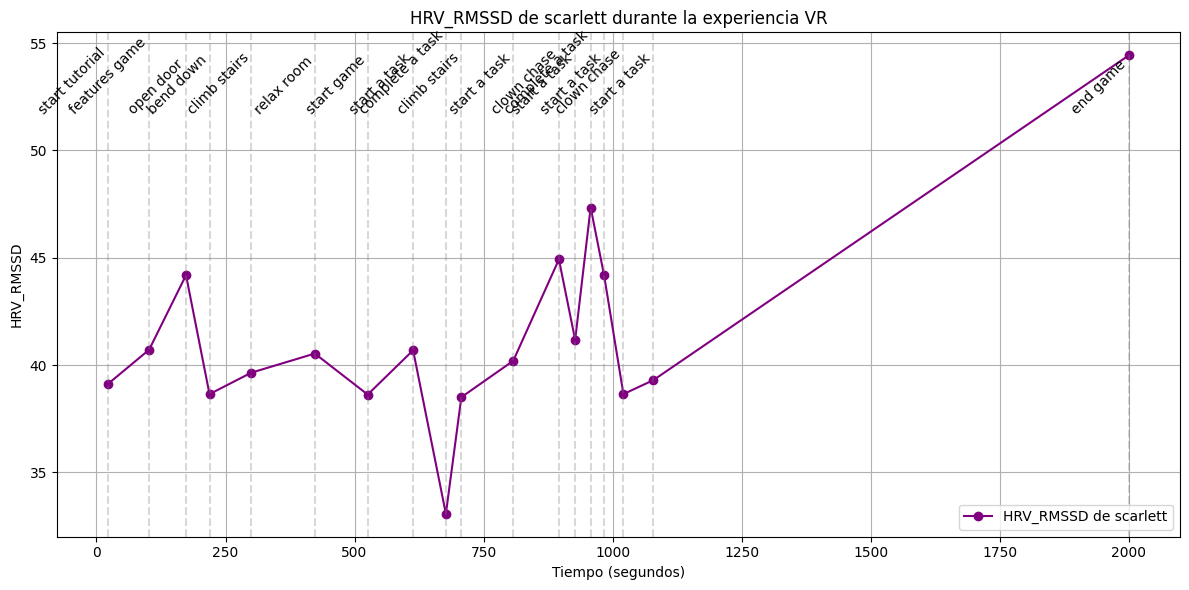

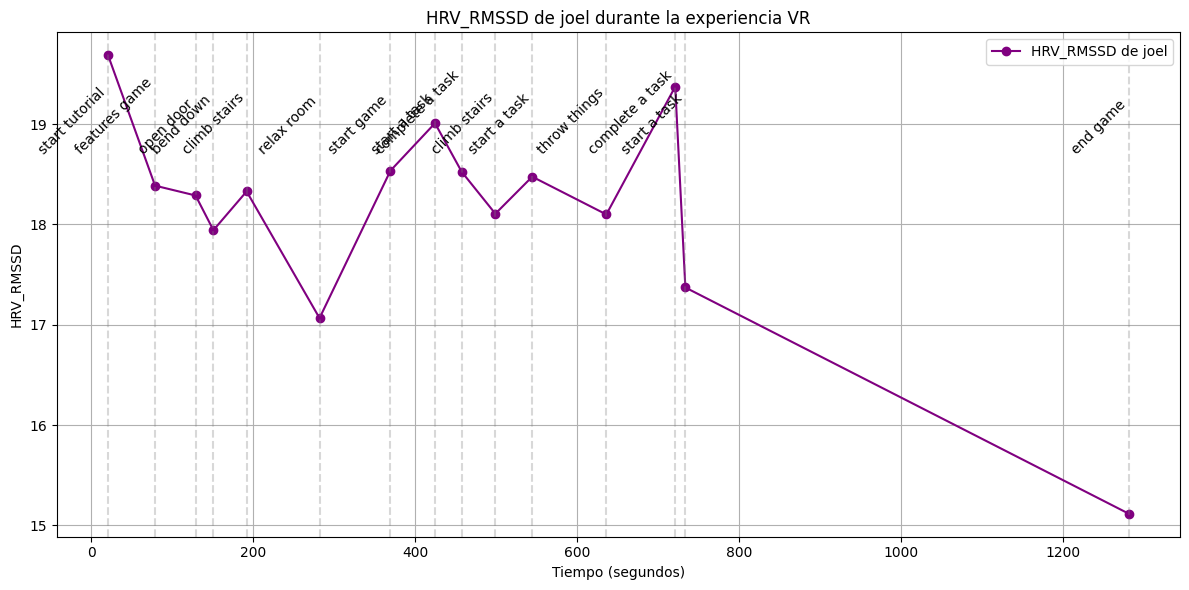

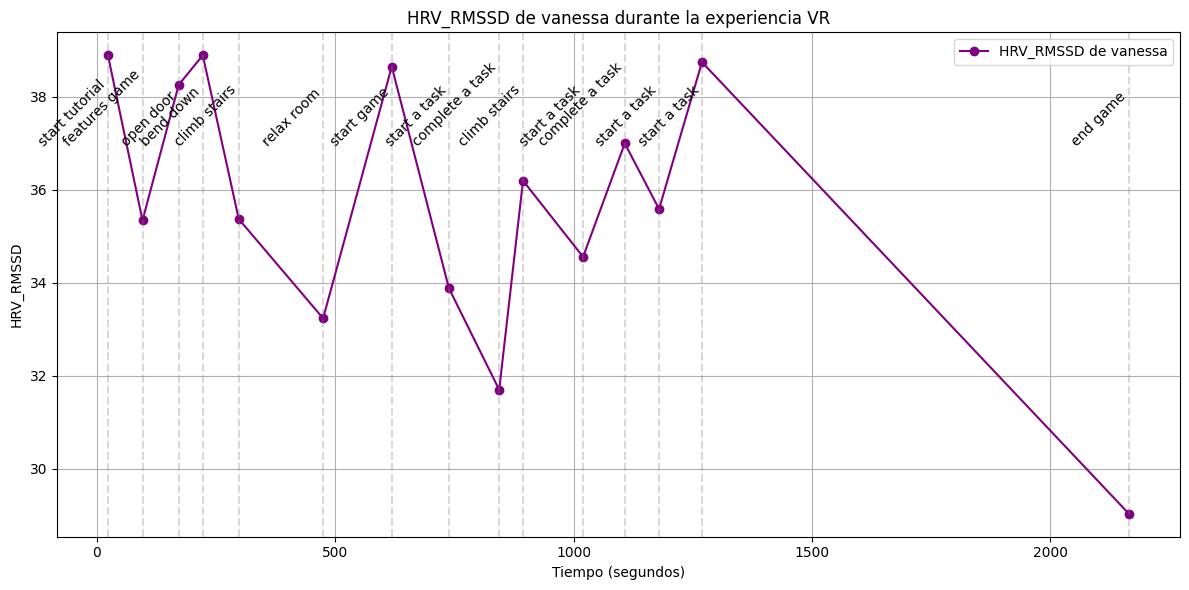

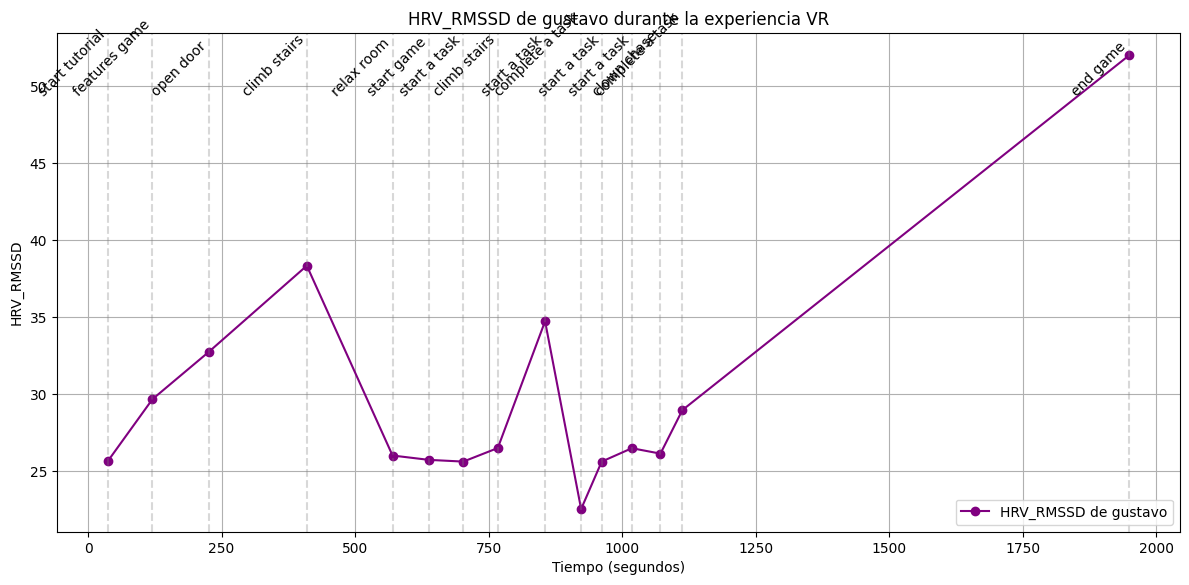

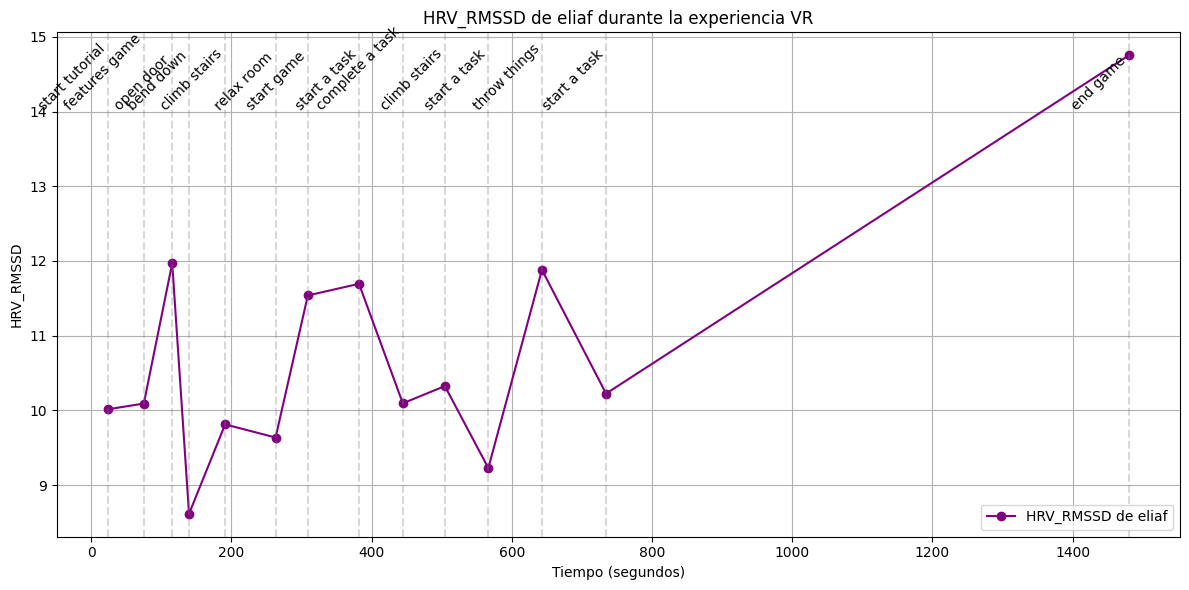

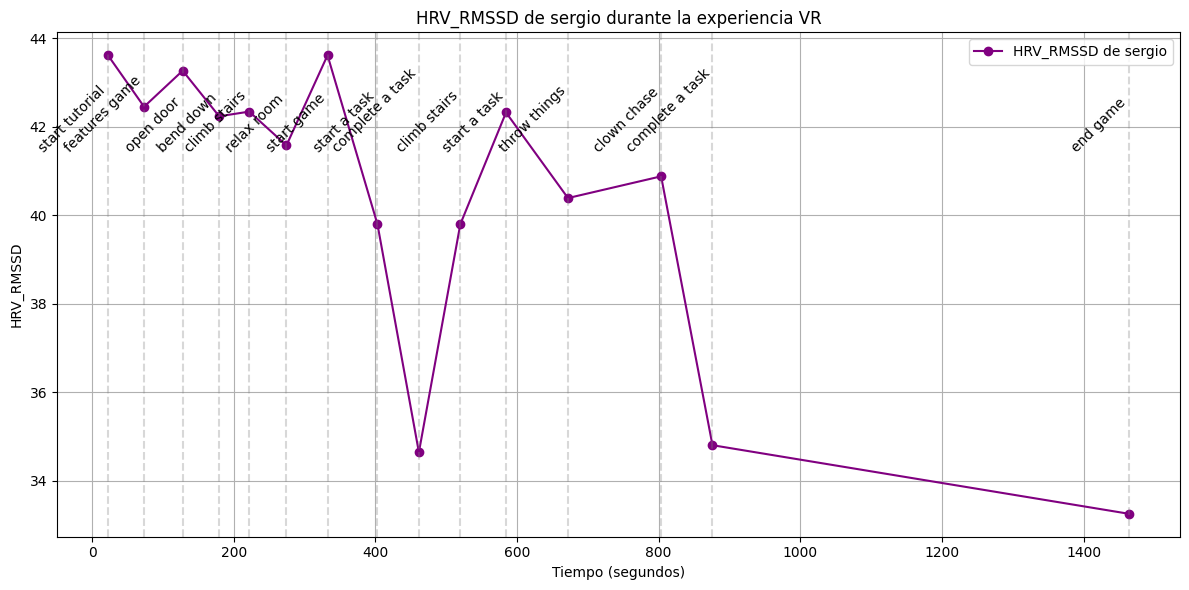

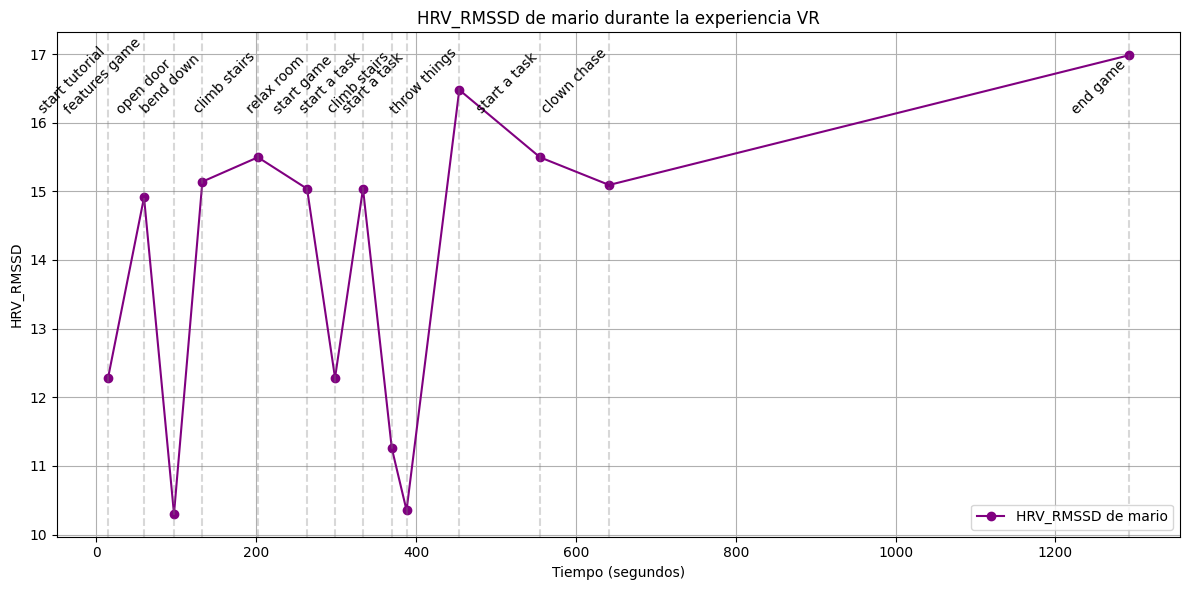

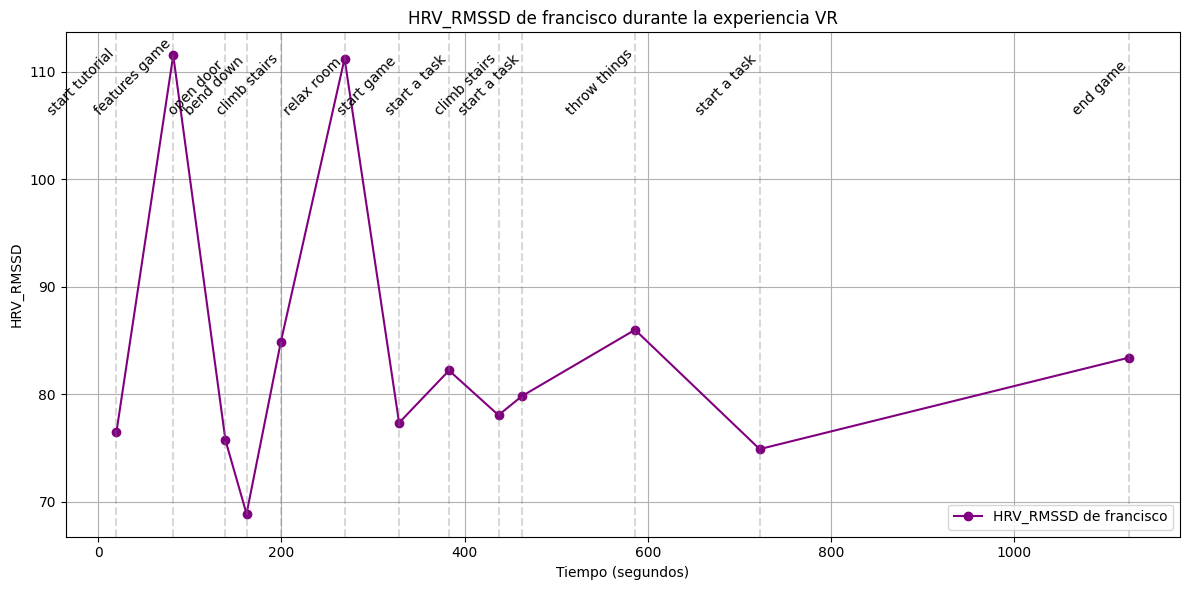

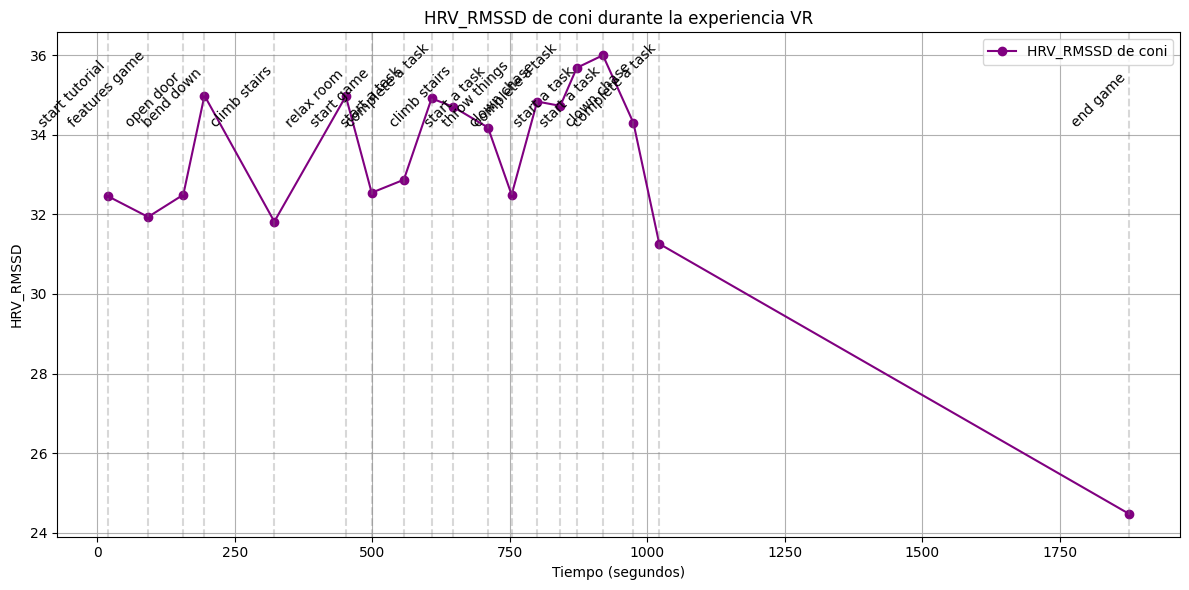

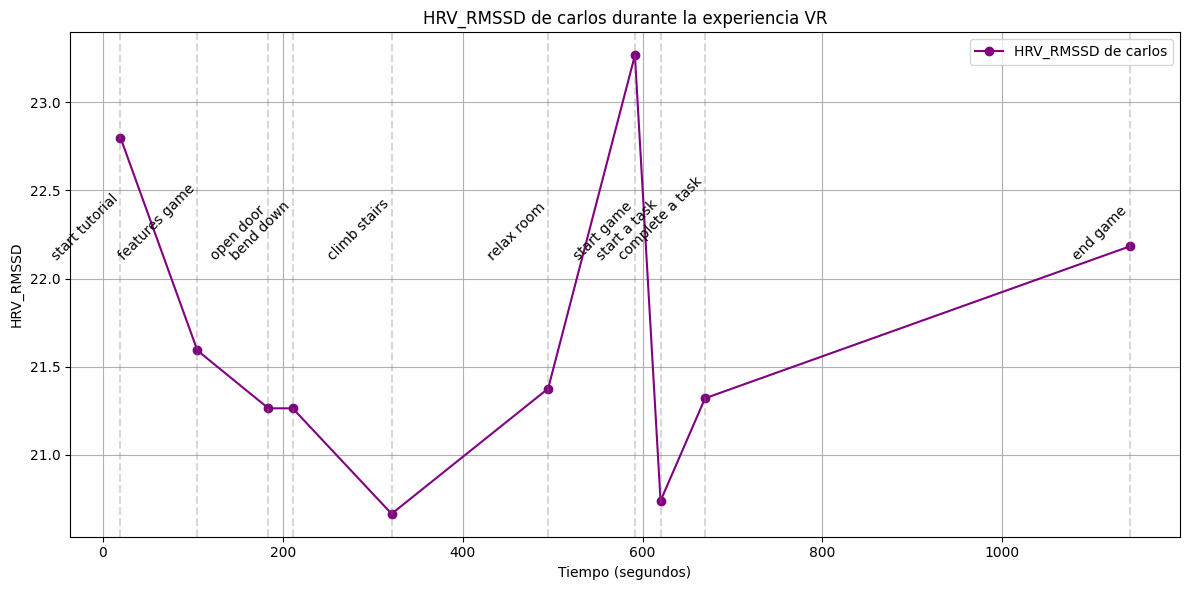

In [ ]:
def plot_summary_hrv_by_event(event_features_df, hrv_column='HRV_SDNN'):
    for participant in event_features_df["user"].unique():
        data = event_features_df[event_features_df["user"] == participant].sort_values("event_start_time")

        plt.figure(figsize=(12, 6))

        # Tiempo medio de cada evento
        time_points = (data["event_start_time"] + data["event_end_time"]) / 2
        hrv_values = data[hrv_column].values
        event_labels = data["event_type"].values

        # Graficar HRV como función del tiempo
        plt.plot(time_points, hrv_values, marker='o', linestyle='-', color='purple', label=f"{hrv_column} de {participant}")

        # Etiquetas de eventos
        for x, label in zip(time_points, event_labels):
            plt.axvline(x=x, color='gray', linestyle='--', alpha=0.3)
            plt.text(x, max(hrv_values) * 0.95, label, rotation=45, ha="right", fontsize=10)

        plt.title(f"{hrv_column} de {participant} durante la experiencia VR")
        plt.xlabel("Tiempo (segundos)")
        plt.ylabel(hrv_column)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

# Visualizar HRV_SDNN
plot_summary_hrv_by_event(event_features_df, hrv_column='HRV_RMSSD')

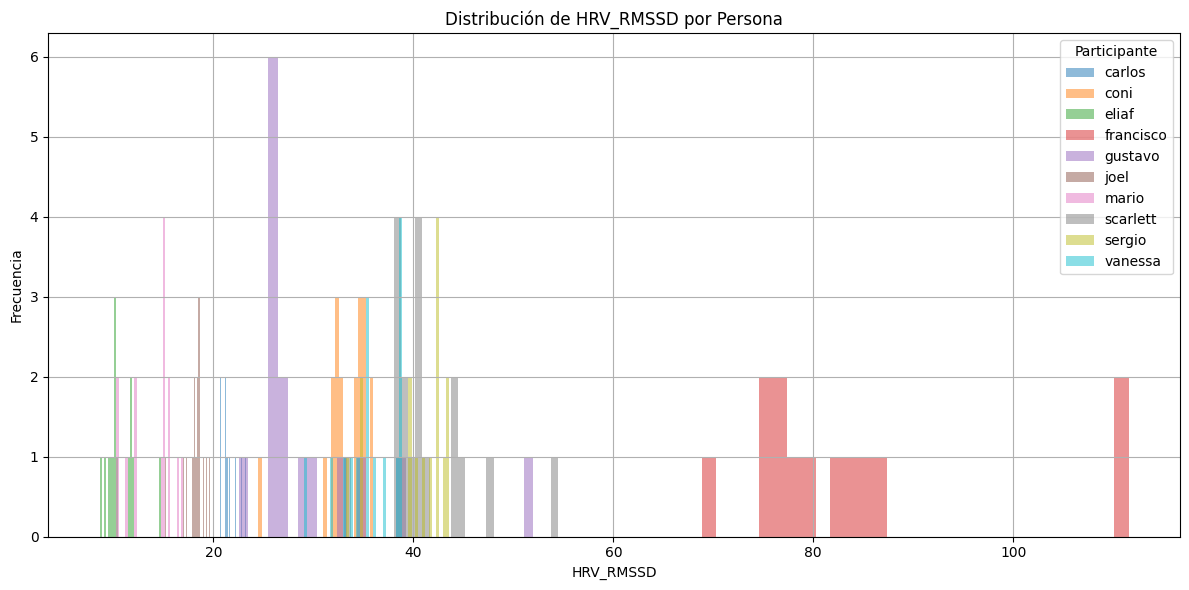

In [ ]:
def plot_hrv_histograms_by_person(event_features_df, hrv_column="HRV_SDNN", bins=30):
    """
    Genera histogramas de una métrica HRV por persona, basada en valores por evento.
    """
    unique_users = sorted(event_features_df["user"].unique())

    plt.figure(figsize=(12, 6))

    for user in unique_users:
        subset = event_features_df[event_features_df["user"] == user][hrv_column].dropna()
        plt.hist(subset, bins=bins, alpha=0.5, label=user)

    plt.title(f"Distribución de {hrv_column} por Persona")
    plt.xlabel(hrv_column)
    plt.ylabel("Frecuencia")
    plt.legend(title="Participante")
    plt.grid()
    plt.tight_layout()
    plt.show()

# Llamada a la función
plot_hrv_histograms_by_person(event_features_df, hrv_column="HRV_RMSSD")

**Observaciones**

* La mayoría de los participantes presentan valores de HRV_RMSSD en rangos moderados, aproximadamente entre 15 y 50 ms, lo cual es esperable en situaciones de atención o leve activación fisiológica.

* Sin embargo, Francisco destaca claramente por presentar valores mucho más altos (alcanzando más de 110 ms), lo que sugiere una alta actividad parasimpática o un mayor nivel de relajación o autorregulación durante la experiencia en realidad virtual.

* En contraste, participantes como Eliaf, Mario y Gustavo muestran distribuciones desplazadas hacia valores más bajos, lo que podría reflejar mayor activación simpática o estrés fisiológico, o una menor capacidad de recuperación ante los estímulos del entorno.

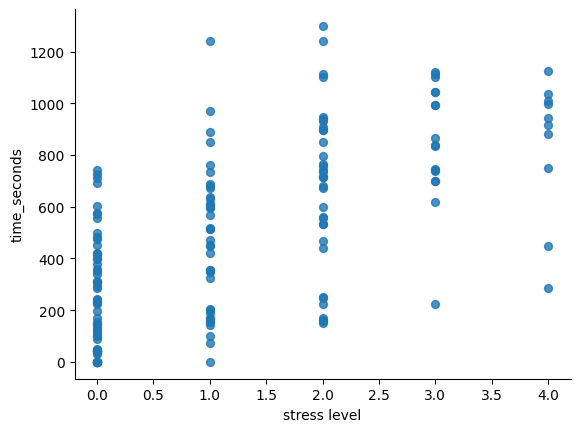

In [ ]:
# Estres contra el tiempo en segundos
data.plot(kind='scatter', x='stress level', y='time_seconds', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

### **Selección de características**

Durante el proceso de limpieza de datos, se identificaron columnas y filas que contenían una proporción significativa de valores faltantes (NaN). Para garantizar la calidad del conjunto de datos utilizado en el análisis y en la construcción de modelos, se aplicó el siguiente criterio:

Filtrado de columnas:

* Se calculó el porcentaje de valores nulos por cada columna del DataFrame.

* Aquellas columnas que presentaban más del 50% de sus valores faltantes fueron eliminadas, ya que su nivel de completitud no era suficiente para contribuir de manera confiable al análisis.

Filtrado de filas:

* De forma similar, se calcularon los valores faltantes a nivel de cada fila.

* Las filas que tenían más del 50% de sus columnas vacías también fueron eliminadas, para asegurar que cada instancia de datos tuviera una cantidad mínima de información válida.

Este procedimiento permite mantener un equilibrio entre cantidad y calidad de datos, evitando el uso de características o instancias que podrían introducir sesgos, ruido o deteriorar el rendimiento de los modelos de clasificación posteriores.



In [ ]:
event_features_df

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_HTI,HRV_TINN,user,event_type,event_start_time,event_end_time,sex,VR experience,heart/stress,stress level
0,646.266667,33.432700,NaN,NaN,NaN,NaN,NaN,NaN,39.119862,39.555431,...,7.500000,85.9375,scarlett,start tutorial,0,44,0,0,0,0
1,662.660870,38.672690,NaN,NaN,NaN,NaN,NaN,NaN,40.717146,40.876954,...,8.846154,62.5000,scarlett,features game,45,159,0,0,0,0
2,654.285714,34.486559,NaN,NaN,NaN,NaN,NaN,NaN,44.191502,44.999842,...,7.000000,93.7500,scarlett,open door,160,187,0,0,0,1
3,649.809524,32.645139,NaN,NaN,NaN,NaN,NaN,NaN,38.650418,38.956406,...,7.000000,85.9375,scarlett,bend down,188,250,0,0,0,1
4,657.949495,35.862940,NaN,NaN,NaN,NaN,NaN,NaN,39.649099,39.849518,...,7.615385,62.5000,scarlett,climb stairs,251,349,0,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,907.806452,39.063900,NaN,NaN,NaN,NaN,NaN,NaN,21.375736,21.433932,...,9.687500,171.8750,carlos,relax room,418,572,1,0,0,0
144,905.631579,35.916887,NaN,NaN,NaN,NaN,NaN,NaN,23.265797,23.484645,...,5.428571,125.0000,carlos,start game,573,610,1,0,0,0
145,917.789474,24.744425,NaN,NaN,NaN,NaN,NaN,NaN,20.739120,21.217517,...,3.800000,62.5000,carlos,start a task,611,629,1,0,1,1
146,904.312500,29.513178,NaN,NaN,NaN,NaN,NaN,NaN,21.320935,21.454616,...,7.272727,93.7500,carlos,complete a task,630,709,1,0,1,1


In [ ]:
# Calculamos porcentaje de datos nulos por columna
null_percentage = event_features_df.isnull().sum() * 100 / len(event_features_df)

# Dejamos como límite el 50% de los datos (si más de la mitad de los datos son nulos, eliminamos la columna)
threshold = 50

columns_to_drop = null_percentage[null_percentage > threshold].index

event_features_df = event_features_df.drop(columns=columns_to_drop)
event_features_df

,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MedianNN,HRV_MadNN,HRV_MCVNN,HRV_IQRNN,...,HRV_HTI,HRV_TINN,user,event_type,event_start_time,event_end_time,sex,VR experience,heart/stress,stress level
0,646.266667,33.432700,39.119862,39.555431,0.051732,0.060532,644.0,26.6868,0.041439,38.00,...,7.500000,85.9375,scarlett,start tutorial,0,44,0,0,0,0
1,662.660870,38.672690,40.717146,40.876954,0.058360,0.061445,657.0,35.5824,0.054159,51.00,...,8.846154,62.5000,scarlett,features game,45,159,0,0,0,0
2,654.285714,34.486559,44.191502,44.999842,0.052709,0.067542,647.5,27.4281,0.042360,38.25,...,7.000000,93.7500,scarlett,open door,160,187,0,0,0,1
3,649.809524,32.645139,38.650418,38.956406,0.050238,0.059480,646.0,23.7216,0.036721,34.00,...,7.000000,85.9375,scarlett,bend down,188,250,0,0,0,1
4,657.949495,35.862940,39.649099,39.849518,0.054507,0.060262,652.0,31.1346,0.047752,43.00,...,7.615385,62.5000,scarlett,climb stairs,251,349,0,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,907.806452,39.063900,21.375736,21.433932,0.043031,0.023547,906.0,35.5824,0.039274,46.00,...,9.687500,171.8750,carlos,relax room,418,572,1,0,0,0
144,905.631579,35.916887,23.265797,23.484645,0.039659,0.025690,910.0,34.0998,0.037472,47.00,...,5.428571,125.0000,carlos,start game,573,610,1,0,0,0
145,917.789474,24.744425,20.739120,21.217517,0.026961,0.022597,926.0,25.2042,0.027218,40.00,...,3.800000,62.5000,carlos,start a task,611,629,1,0,1,1
146,904.312500,29.513178,21.320935,21.454616,0.032636,0.023577,905.5,28.9107,0.031928,37.75,...,7.272727,93.7500,carlos,complete a task,630,709,1,0,1,1


In [ ]:
# Hacemos lo mismo con las filas (eliminamos las que tengan más del 50% de sus datos nulos)
threshold = 0.5
row_null_percentage = event_features_df.isnull().sum(axis=1) / len(event_features_df.columns)
event_features_df = event_features_df[row_null_percentage < threshold]

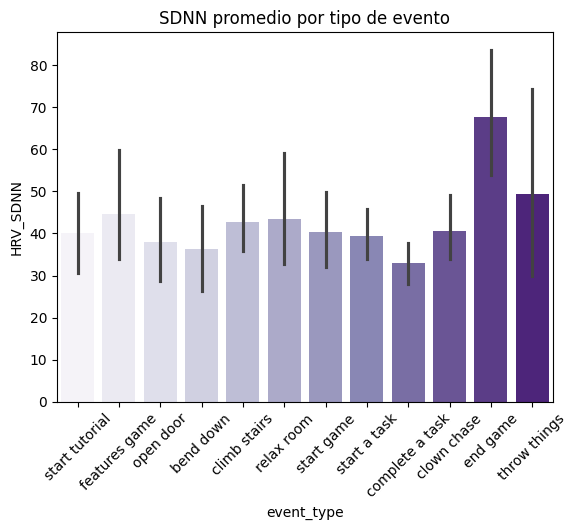

In [ ]:
sns.barplot(data=event_features_df, x='event_type', y='HRV_SDNN', hue= 'event_type', palette="Purples")
plt.xticks(rotation=45)
plt.title('SDNN promedio por tipo de evento')
plt.show()

 **Observaciones**

 La figura obtenida se muestra el promedio de SDNN registrado para cada uno de los contextos vividos por los participantes. Se observa que eventos como end game y clown chase presentan valores más altos de SDNN, lo cual puede estar relacionado con respuestas emocionales intensas o una mayor activación fisiológica. Por el contrario, actividades como complete a task o bend down muestran menor variabilidad, asociadas posiblemente a momentos más controlados o repetitivos de la experiencia.

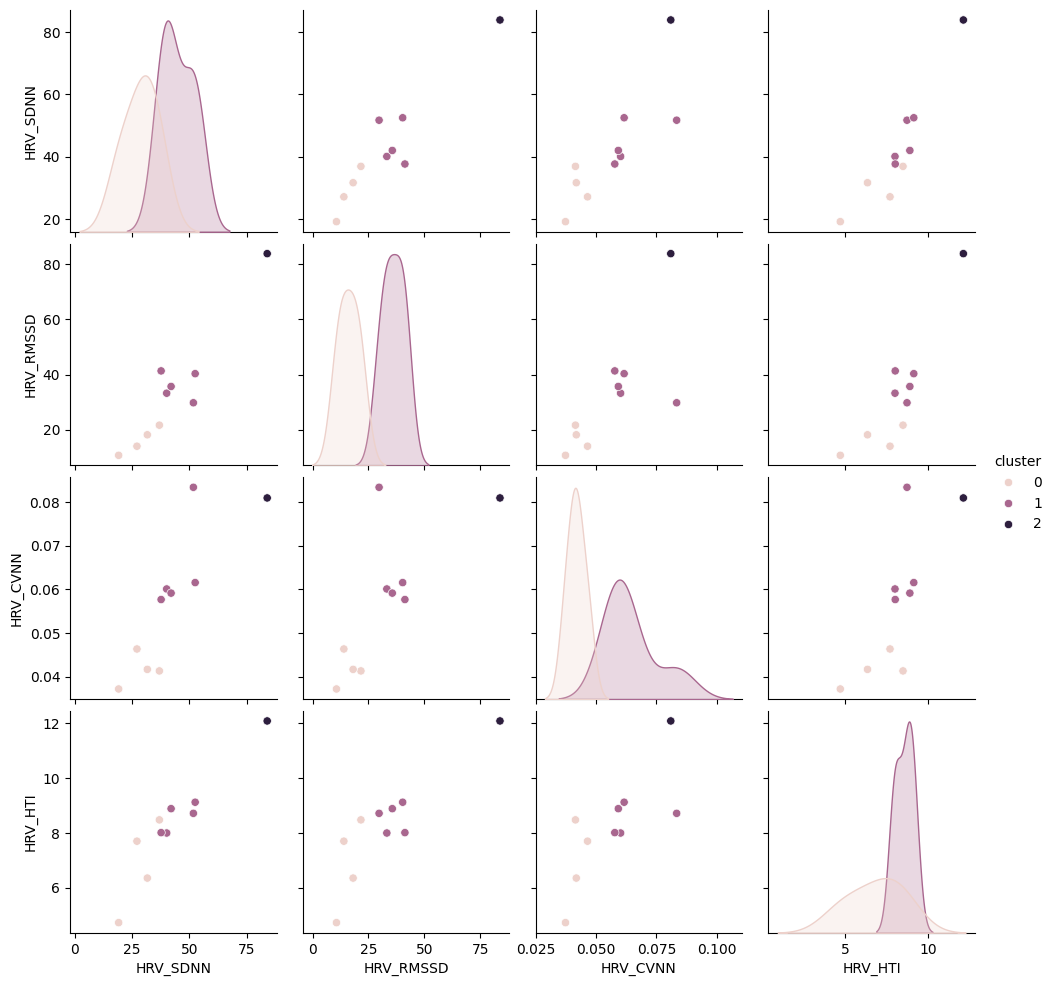

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = event_features_df.groupby('user')[['HRV_SDNN', 'HRV_RMSSD', 'HRV_CVNN', 'HRV_HTI']].mean()
scaled = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=0).fit(scaled)
features['cluster'] = kmeans.labels_

sns.pairplot(features, hue='cluster')

**Observaciones:**

Complementando este análisis contextual, se llevó a cabo una segmentación no supervisada mediante clustering, utilizando características clave del HRV. La Figura se muestra un pairplot de las variables SDNN, RMSSD, CVNN y HTI, donde los participantes se agrupan en tres clústeres bien definidos: baja variabilidad (menos reactivos), moderada (reactividad balanceada), y alta variabilidad (posiblemente más sensibles o emocionalmente reactivos). Se observa una mayor concentración de participantes en el grupo con variabilidad moderada, lo que sugiere que la mayoría presentó una respuesta fisiológica equilibrada durante la experiencia en realidad virtual.

#### **Construcción y evaluación de modelos**

Se implementaron diversas arquitecturas de aprendizaje automático supervisado con el objetivo de clasificar el nivel de estrés de los participantes a partir de sus características fisiológicas. A continuación, se listan los modelos utilizados:

* Random Forest
* Gaussian Naive Bayes.
* Support Vector Machine (SVM).
* K-Nearest Neighbors (KNN).
* Decision Tree.
* XGBoost.
* Logistic Regression
* Gradient Boosting

**Clasificador multiclase**

Para la clasificación de los niveles de estrés se definieron cinco clases (de 0 a 4), representando desde ausencia hasta un nivel muy alto de estrés.

In [ ]:
# Creamos el mapeo utilizando todos los eventos únicos
event_mapping = {event: i for i, event in enumerate(event_features_df['event_type'].unique())}

# Se convierte la columna a numérica utilizando el mapeo
event_features_df['event_type'] = event_features_df['event_type'].map(event_mapping)

In [ ]:
X = event_features_df.drop(columns=['stress level','user','event_start_time','event_end_time'])
y = event_features_df['stress level']

In [ ]:
print(event_features_df['stress level'].value_counts())

stress level
0    59
1    36
2    30
3    13
4    10
Name: count, dtype: int64


In [ ]:
import warnings
warnings.filterwarnings("ignore")

Pesos por clase: {np.int64(0): np.float64(1.004255319148936), np.int64(1): np.float64(1.0260869565217392), np.int64(2): np.float64(1.004255319148936), np.int64(3): np.float64(1.0727272727272728), np.int64(4): np.float64(0.9076923076923077)}

 Modelo base: Random Forest

Accuracy: 0.8644
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.80      0.92      0.86        13
           2       0.67      0.83      0.74        12
           3       1.00      0.73      0.85        15
           4       1.00      1.00      1.00         7

    accuracy                           0.86        59
   macro avg       0.89      0.88      0.88        59
weighted avg       0.89      0.86      0.87        59



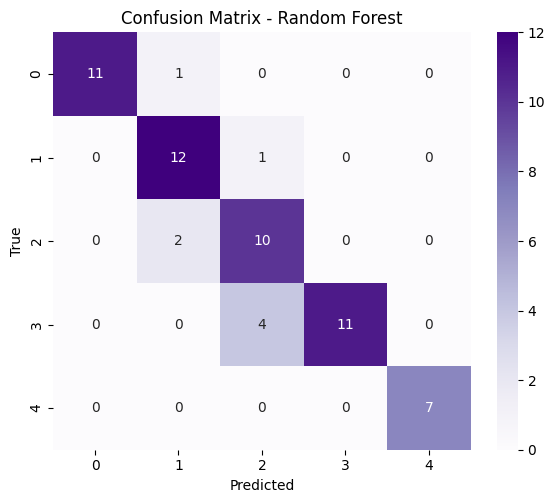


 Comparación con otros modelos:

🔹 Gaussian Naive Bayes Accuracy: 0.7119
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.88      0.54      0.67        13
           2       0.64      0.58      0.61        12
           3       0.55      0.80      0.65        15
           4       0.67      0.57      0.62         7

    accuracy                           0.71        59
   macro avg       0.74      0.70      0.71        59
weighted avg       0.74      0.71      0.71        59



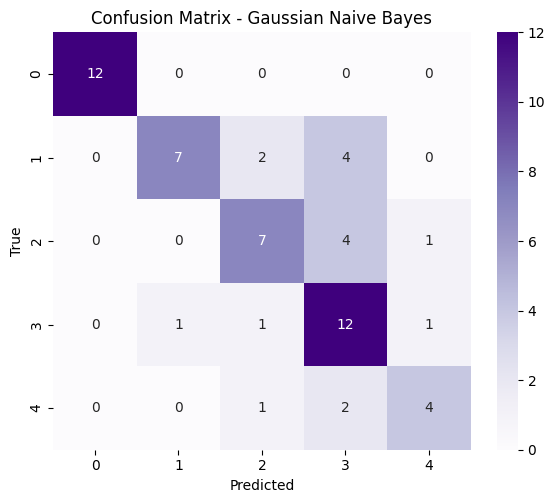

🔹 Support Vector Machine Accuracy: 0.2881
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.43      0.23      0.30        13
           2       0.26      0.67      0.37        12
           3       0.12      0.13      0.13        15
           4       0.80      0.57      0.67         7

    accuracy                           0.29        59
   macro avg       0.32      0.32      0.29        59
weighted avg       0.27      0.29      0.25        59



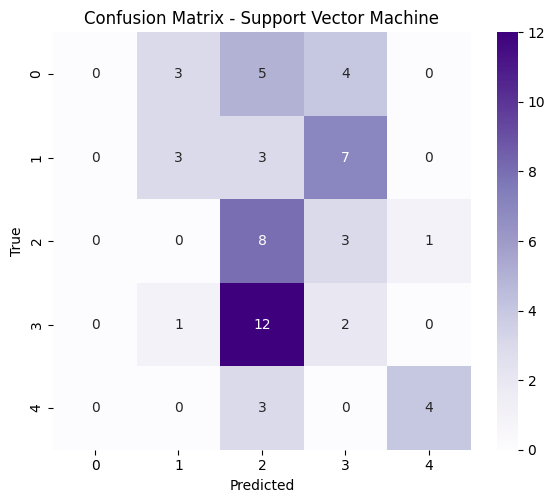

🔹 K-Nearest Neighbors Accuracy: 0.6271
              precision    recall  f1-score   support

           0       0.56      0.75      0.64        12
           1       0.60      0.69      0.64        13
           2       0.54      0.58      0.56        12
           3       0.83      0.33      0.48        15
           4       0.78      1.00      0.88         7

    accuracy                           0.63        59
   macro avg       0.66      0.67      0.64        59
weighted avg       0.66      0.63      0.61        59



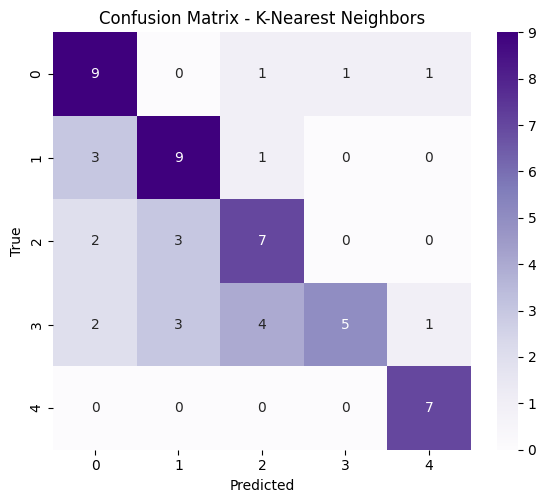

🔹 Decision Tree Accuracy: 0.7966
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.63      0.92      0.75        13
           2       0.64      0.58      0.61        12
           3       0.91      0.67      0.77        15
           4       1.00      1.00      1.00         7

    accuracy                           0.80        59
   macro avg       0.84      0.82      0.82        59
weighted avg       0.82      0.80      0.80        59



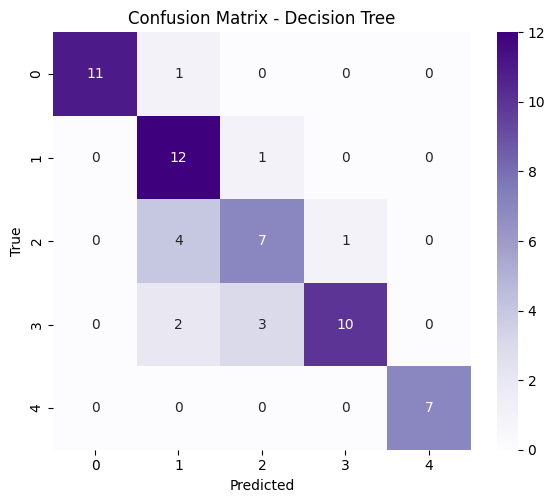

🔹 XGBoost Accuracy: 0.8475
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.79      0.85      0.81        13
           2       0.62      0.67      0.64        12
           3       1.00      0.80      0.89        15
           4       0.88      1.00      0.93         7

    accuracy                           0.85        59
   macro avg       0.86      0.86      0.86        59
weighted avg       0.86      0.85      0.85        59



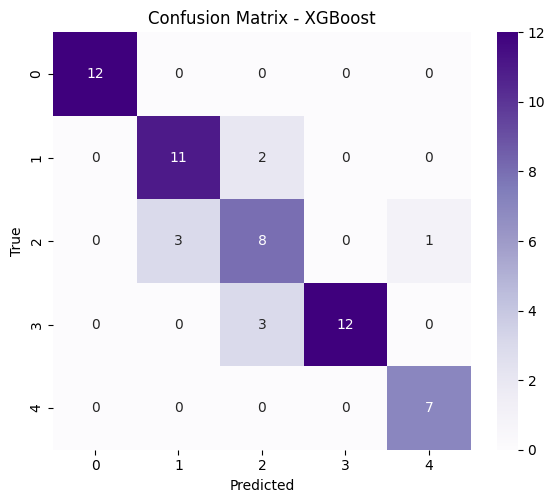

🔹 Logistic Regression Accuracy: 0.4407
              precision    recall  f1-score   support

           0       0.31      0.67      0.42        12
           1       0.40      0.15      0.22        13
           2       0.17      0.08      0.11        12
           3       0.75      0.60      0.67        15
           4       0.60      0.86      0.71         7

    accuracy                           0.44        59
   macro avg       0.44      0.47      0.43        59
weighted avg       0.45      0.44      0.41        59



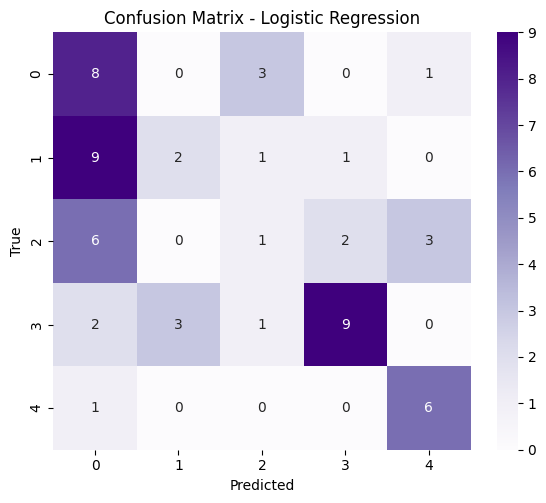

🔹 Gradient Boosting Accuracy: 0.8475
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.79      0.85      0.81        13
           2       0.60      0.75      0.67        12
           3       1.00      0.80      0.89        15
           4       1.00      1.00      1.00         7

    accuracy                           0.85        59
   macro avg       0.88      0.86      0.87        59
weighted avg       0.87      0.85      0.85        59



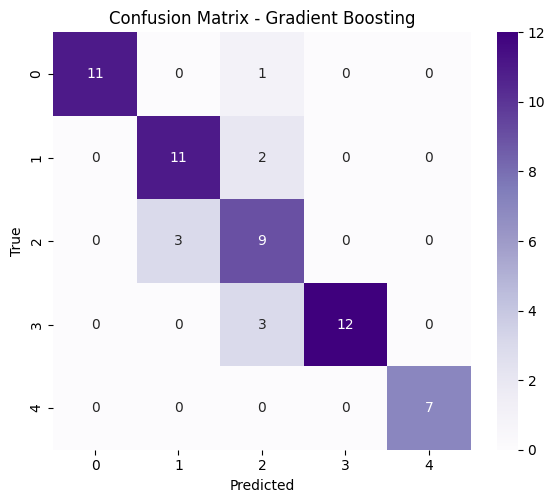

In [ ]:
# División de datos y pesos por clase

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

# Cálculo de pesos de clase balanceados
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(zip(np.unique(y_train), class_weights))

print("Pesos por clase:", class_weights_dict)

# Modelo base: Random Forest
print("\n Modelo base: Random Forest\n")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight=class_weights_dict
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Resultados
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {accuracy_rf:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', square=True)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

# Comparación con otros modelos

print("\n Comparación con otros modelos:\n")

models = {
    "Gaussian Naive Bayes": GaussianNB(),  # no usa class_weight
    "Support Vector Machine": SVC(class_weight=class_weights_dict),
    "K-Nearest Neighbors": KNeighborsClassifier(weights='distance'),
    "Decision Tree": DecisionTreeClassifier(class_weight=class_weights_dict),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', scale_pos_weight=1),
    "Logistic Regression": LogisticRegression(class_weight=class_weights_dict),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1),
}

# Evaluación de múltiples modelos
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"🔹 {name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', square=True)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.show()

**Observaciones**

Si bien los modelos Gradient Boosting y XGBoost mostraron un desempeño sólido, el modelo Random Forest fue el que alcanzó la mayor precisión, logrando una exactitud general del 86.44\% sobre el conjunto de prueba.

El modelo mostró un rendimiento sobresaliente en la clasificación de los casos con estrés muy bajo (clase 0) y estrés muy alto (clase 4), donde logró una precisión y recall del 100\% en esta última clase. Las clases intermedias, particularmente el estrés moderado (clase 2), presentaron un rendimiento ligeramente menor, con una F1-score de 0.74, lo cual es esperado en escenarios donde las fronteras entre clases son más difusas.

**Clasificador binario**

Para la clasificación binaria de los niveles de estrés, se agruparon las clases originales en dos categorías:

* Clase 0 (sin estrés): correspondiente a los niveles 0 y 1.
* Clase 1 (con estrés): correspondiente a los niveles 2, 3 y 4.

Esta reagrupación permite simplificar la tarea de detección, enfocándose en distinguir entre momentos de calma y momentos de estrés durante la experiencia en el entorno virtual.

In [ ]:
# Redefinir la variable objetivo como binaria
event_features_df['binary_stress'] = event_features_df['stress level'].apply(lambda x: 0 if x <= 1 else 1)

# Separar X e y
X = event_features_df.drop(columns=['stress level', 'binary_stress', 'user', 'event_start_time', 'event_end_time'])
y = event_features_df['binary_stress']


 Modelo base: Random Forest

Accuracy: 0.8947
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90        20
           1       0.94      0.83      0.88        18

    accuracy                           0.89        38
   macro avg       0.90      0.89      0.89        38
weighted avg       0.90      0.89      0.89        38



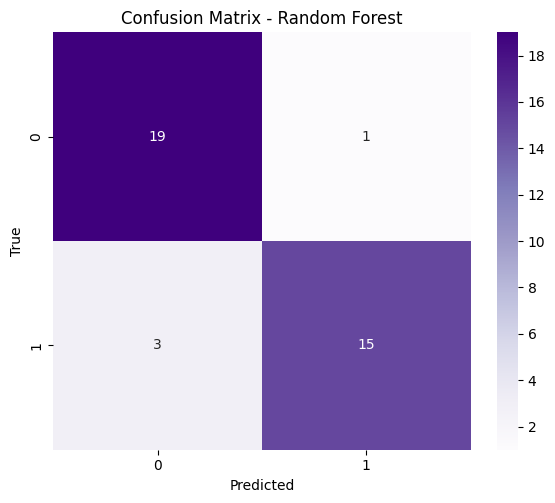


 Comparación con otros modelos:

🔹 Gaussian Naive Bayes Accuracy: 0.8947
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        20
           1       0.82      1.00      0.90        18

    accuracy                           0.89        38
   macro avg       0.91      0.90      0.89        38
weighted avg       0.91      0.89      0.89        38



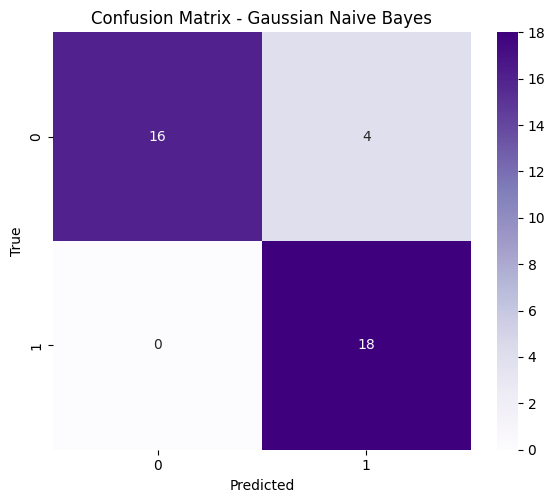

🔹 Support Vector Machine Accuracy: 0.6316
              precision    recall  f1-score   support

           0       0.88      0.35      0.50        20
           1       0.57      0.94      0.71        18

    accuracy                           0.63        38
   macro avg       0.72      0.65      0.60        38
weighted avg       0.73      0.63      0.60        38



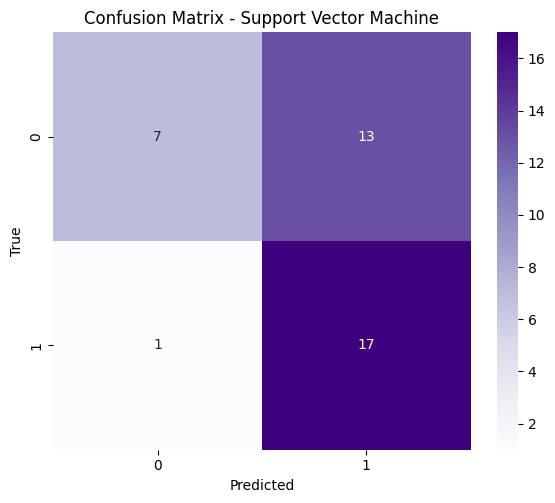

🔹 K-Nearest Neighbors Accuracy: 0.6053
              precision    recall  f1-score   support

           0       0.62      0.65      0.63        20
           1       0.59      0.56      0.57        18

    accuracy                           0.61        38
   macro avg       0.60      0.60      0.60        38
weighted avg       0.60      0.61      0.60        38



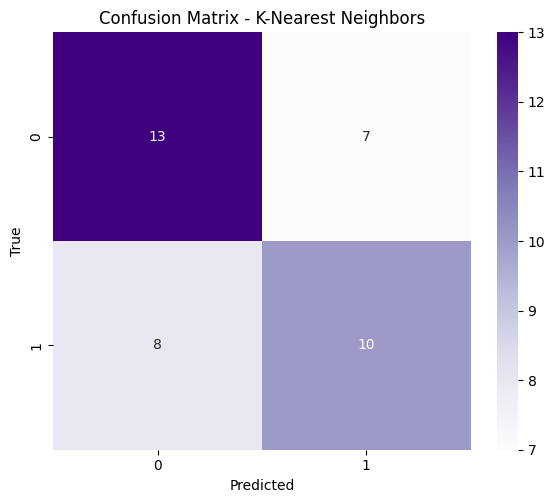

🔹 Decision Tree Accuracy: 0.8684
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        20
           1       0.88      0.83      0.86        18

    accuracy                           0.87        38
   macro avg       0.87      0.87      0.87        38
weighted avg       0.87      0.87      0.87        38



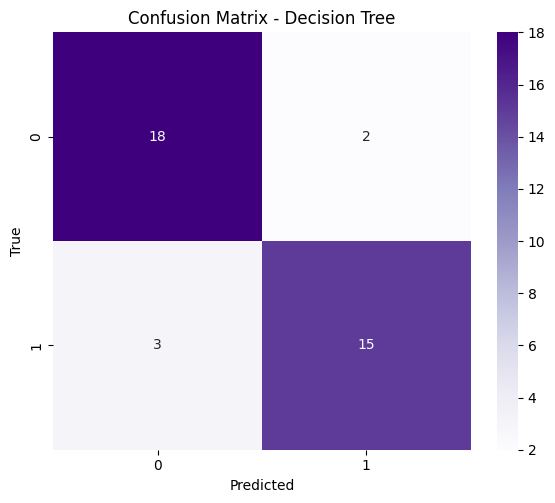

🔹 XGBoost Accuracy: 0.7895
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        20
           1       0.78      0.78      0.78        18

    accuracy                           0.79        38
   macro avg       0.79      0.79      0.79        38
weighted avg       0.79      0.79      0.79        38



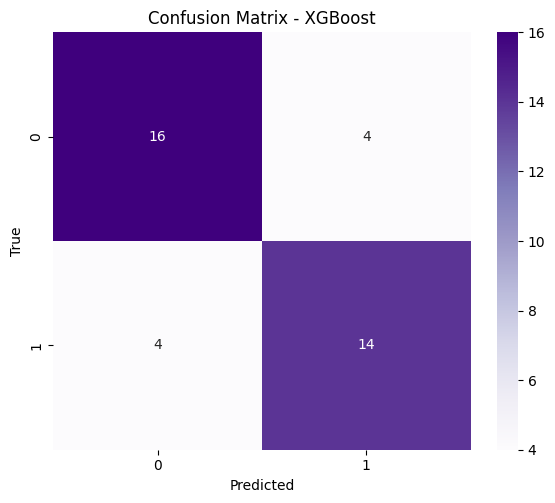

🔹 Logistic Regression Accuracy: 0.8158
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        20
           1       0.82      0.78      0.80        18

    accuracy                           0.82        38
   macro avg       0.82      0.81      0.81        38
weighted avg       0.82      0.82      0.82        38



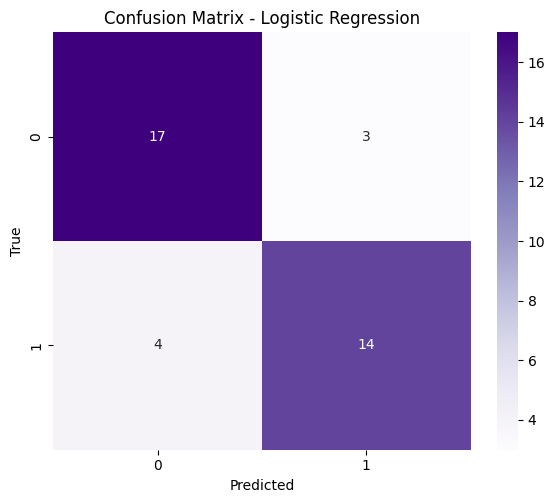

🔹 Gradient Boosting Accuracy: 0.8947
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        20
           1       0.89      0.89      0.89        18

    accuracy                           0.89        38
   macro avg       0.89      0.89      0.89        38
weighted avg       0.89      0.89      0.89        38



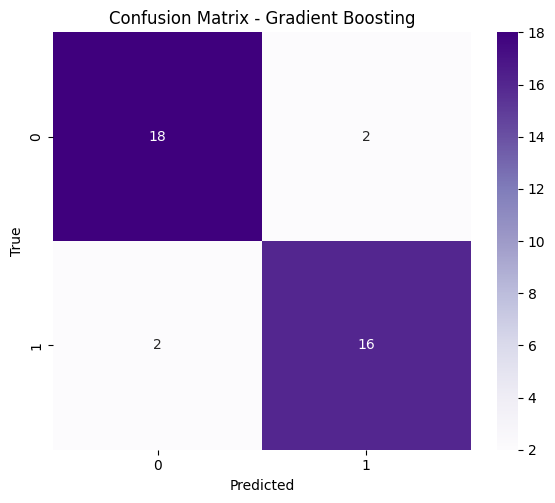

In [ ]:
# SMOTE para balancear
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Pesos por clase
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(zip(np.unique(y_train), class_weights))

# Modelo base: Random Forest
print("\n Modelo base: Random Forest\n")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight=class_weights_dict
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Resultados
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {accuracy_rf:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', square=True)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

# Comparación con otros modelos

print("\n Comparación con otros modelos:\n")

models = {
    "Gaussian Naive Bayes": GaussianNB(),  # no usa class_weight
    "Support Vector Machine": SVC(class_weight=class_weights_dict),
    "K-Nearest Neighbors": KNeighborsClassifier(weights='distance'),
    "Decision Tree": DecisionTreeClassifier(class_weight=class_weights_dict),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', scale_pos_weight=1),
    "Logistic Regression": LogisticRegression(class_weight=class_weights_dict),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1),
}

# Evaluación de múltiples modelos
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"🔹 {name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', square=True)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.show()

Los modelos Random Forest, Decision Tree, Logistic Regression y Gradient Boosting obtuvieron un rendimiento destacado. Sin embargo, el modelo que alcanzó el mejor desempeño general fue el Gaussian Naive Bayes, logrando una exactitud del 89.47\%.

Este modelo obtuvo una excelente precisión (1.00) al clasificar correctamente los casos sin estrés, y una recall (1.00) al identificar correctamente todos los casos con estrés. El F1-score balanceado de 0.90 en ambas clases evidencia su capacidad para distinguir con eficacia entre participantes relajados y aquellos que experimentaron estrés durante la simulación.

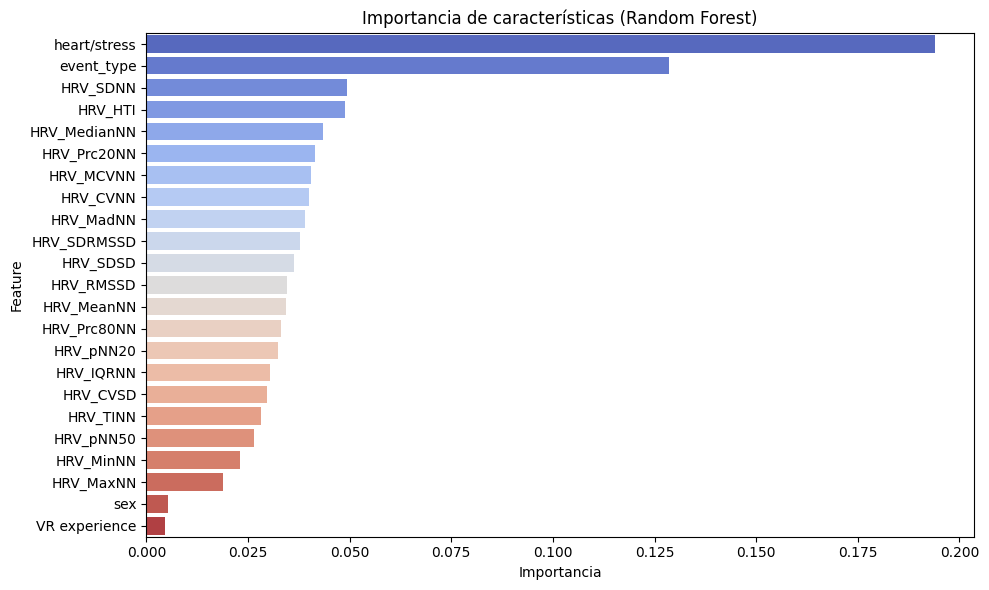

In [ ]:
# Asumiendo que ya entrenaste rf_model
importances = rf_model.feature_importances_
features = X_train.columns

# Crear un dataframe ordenado
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Visualizar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette="coolwarm")
plt.xlabel('Importancia')
plt.title("Importancia de características (Random Forest)")
plt.tight_layout()
plt.show()

Una vez entrenado el modelo de Random Forest, se evaluó la relevancia de cada característica utilizada para predecir el nivel de estrés.

* heart/stress (una variable de referencia o estado previo al evento) resultó ser la característica más influyente, lo que sugiere que el estado fisiológico inicial del participante tiene un fuerte peso en la predicción del estrés.

* event_type, que codifica el tipo de situación dentro del entorno virtual, también mostró una alta relevancia, lo cual refuerza la idea de que ciertos eventos (como "clown chase" o "start task") están más asociados a respuestas fisiológicas de estrés.

* Dentro de las características derivadas del HRV, destacan:

  * HRV_SDNN: representa la variabilidad total de los intervalos RR.

  * HRV_HTI: índice triangular de HRV, relacionado con la estabilidad del ritmo.

  * HRV_MedianNN y HRV_Prc20NN: estadísticas de tendencia central y percentiles, útiles para capturar diferencias sutiles en la respuesta fisiológica.

  * Otras métricas de HRV como CVNN, MCVNN y RMSSD también aportaron al modelo, aunque con menor peso relativo.

Las variables sociodemográficas como sexo y experiencia en VR tuvieron una contribución muy baja, lo que sugiere que las señales fisiológicas y contextuales son mucho más determinantes que los factores personales en este conjunto de datos.

In [ ]:
!pip install lime --quiet

In [ ]:
explainer = LimeTabularExplainer(X_train.values, feature_names=X_train.columns, class_names=['Bajo', 'Alto'], mode='classification')
exp = explainer.explain_instance(X_test.values[0], rf_model.predict_proba)
exp.show_in_notebook()

#### **Conclusiones y principales hallagos**

Los resultados obtenidos en este estudio indican que es posible detectar distintos niveles de estrés en participantes que interactúan con entornos virtuales, a partir del análisis de características derivadas de la variabilidad de la frecuencia cardíaca (HRV). Este hallazgo coincide con trabajos previos como el de Lee, S. et al. (2022), donde también se empleó HRV para estimar niveles de estrés, aunque en contextos no inmersivos.

El modelo Random Forest demostró ser el más efectivo en la clasificación multiclase, mientras que Gaussian Naive Bayes destacó en la clasificación binaria, lo que sugiere que distintos enfoques pueden ser óptimos según el objetivo deseada.

Asimismo, el análisis por eventos permitió identificar momentos específicos del juego con mayor impacto fisiológico (por ejemplo, clown chase o end game), y el clustering reveló perfiles fisiológicos diferenciados entre los participantes, lo que refuerza la importancia de considerar variabilidad interindividual en estudios de estrés.


#### **Limitaciones del estudio**

El tamaño de la muestra fue reducido (n = 10), lo que limita la generalización de los resultados a poblaciones más amplias y diversas.

Se utilizó únicamente el sensor Polar H10 para la recolección de datos fisiológicos, centrando el análisis exclusivamente en la señal de variabilidad de la frecuencia cardíaca (HRV). Esto implica que otras variables relevantes en la detección de estrés, como la respuesta galvánica cutánea (GRS), electromiograma (EMG), o la temperatura corporal, no fueron consideradas en este proyecto.

#### **Trabajo a futuro**

Los resultados obtenidos en este estudio demuestran que es posible detectar niveles de estrés en entornos de realidad virtual mediante el análisis de características fisiológicas derivadas del HRV.

Este trabajo constituye un primer paso hacia el desarrollo de sistemas inteligentes capaces de monitorear y responder al estado emocional del usuario en entornos virtuales. No obstante, existen varias oportunidades para extender y mejorar este enfoque. Entre las principales líneas de trabajo a futuro se incluyen la ampliación de la muestra, la integración de señales fisiológicas adicionales (como EMG o respiración), la exploración de nuevos escenarios virtuales con diferentes estímulos emocionales, la evaluación del modelo en tiempo real y la incorporación de medidas psicológicas subjetivas.

Estas mejoras no solo permitirán fortalecer la validez del sistema propuesto, sino que también contribuirán al desarrollo de experiencias virtuales adaptativas, más seguras, inmersivas y centradas en el usuario.